<a href="https://www.kaggle.com/code/lalit7881/bank-customer-churn-eda-66-85?scriptVersionId=353811880" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/srisyra02/bank-customer-churn-prediction/Customer-Churn-Records.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/srisyra02/bank-customer-churn-prediction/Customer-Churn-Records.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts
0,1,15574012,Chu,645,Spain,Male,44,8,113755.78,2
1,2,15592531,Bartlett,822,France,Male,50,7,0.00,2
2,3,15656148,Obinna,376,Germany,Female,29,4,115046.74,4
3,4,15792365,He,501,France,Male,44,4,142051.07,2
4,5,15592389,H?,684,France,Male,27,2,134603.88,1


In [4]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2
9996,9997,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2
9997,9998,15628319,Walker,792,France,Female,28,4,130142.79,1
9998,9999,15569892,Johnstone,516,France,Male,35,10,57369.61,1
9999,10000,15584532,Liu,709,France,Female,36,7,0.00,1


In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000


In [6]:
df.isnull().sum()

RowNumber        0
CustomerId       0
Surname          0
CreditScore      0
Geography        0
Gender           0
Age              0
Tenure           0
Balance          0
NumOfProducts    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts'],
      dtype='object')

In [9]:
df.nunique()

RowNumber        10000
CustomerId       10000
Surname           2932
CreditScore        460
Geography            3
Gender               2
Age                 70
Tenure              11
Balance           6382
NumOfProducts        4
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   RowNumber      10000 non-null  int64  
 1   CustomerId     10000 non-null  int64  
 2   Surname        10000 non-null  object 
 3   CreditScore    10000 non-null  int64  
 4   Geography      10000 non-null  object 
 5   Gender         10000 non-null  object 
 6   Age            10000 non-null  int64  
 7   Tenure         10000 non-null  int64  
 8   Balance        10000 non-null  float64
 9   NumOfProducts  10000 non-null  int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 781.4+ KB


## EDA

Dataset Shape: (10000, 10)

Columns:
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts'],
      dtype='object')

DATASET INFORMATION

First 5 Rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts
0,1,15574012,Chu,645,Spain,Male,44,8,113755.78,2
1,2,15592531,Bartlett,822,France,Male,50,7,0.00,2
2,3,15656148,Obinna,376,Germany,Female,29,4,115046.74,4
3,4,15792365,He,501,France,Male,44,4,142051.07,2
4,5,15592389,H?,684,France,Male,27,2,134603.88,1



Last 5 Rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2
9996,9997,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2
9997,9998,15628319,Walker,792,France,Female,28,4,130142.79,1
9998,9999,15569892,Johnstone,516,France,Male,35,10,57369.61,1
9999,10000,15584532,Liu,709,France,Female,36,7,0.00,1



Dataset Shape:
(10000, 10)

Data Types:
RowNumber          int64
CustomerId         int64
Surname           object
CreditScore        int64
Geography         object
Gender            object
Age                int64
Tenure             int64
Balance          float64
NumOfProducts      int64
dtype: object

Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


No missing values found.

Number of Duplicate Rows: 0

Numerical Columns:
['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts']

Categorical Columns:
['Surname', 'Geography', 'Gender']


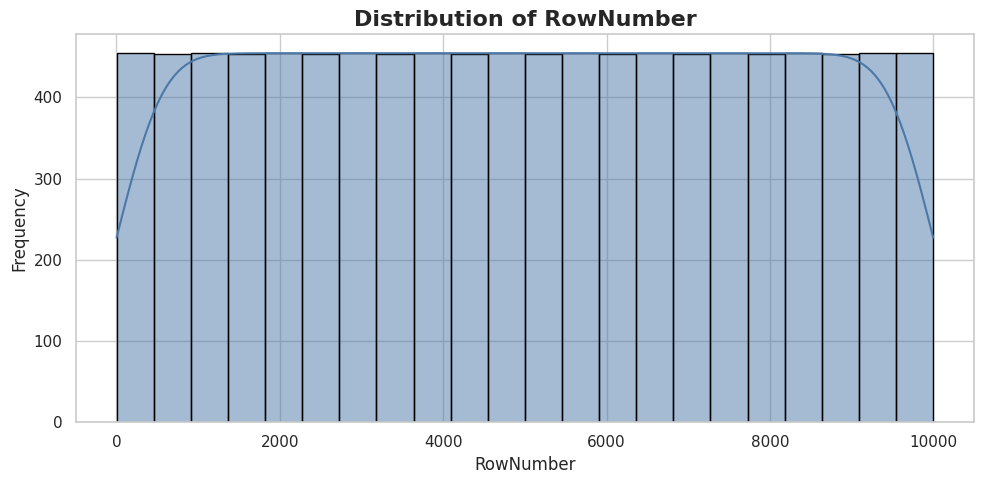

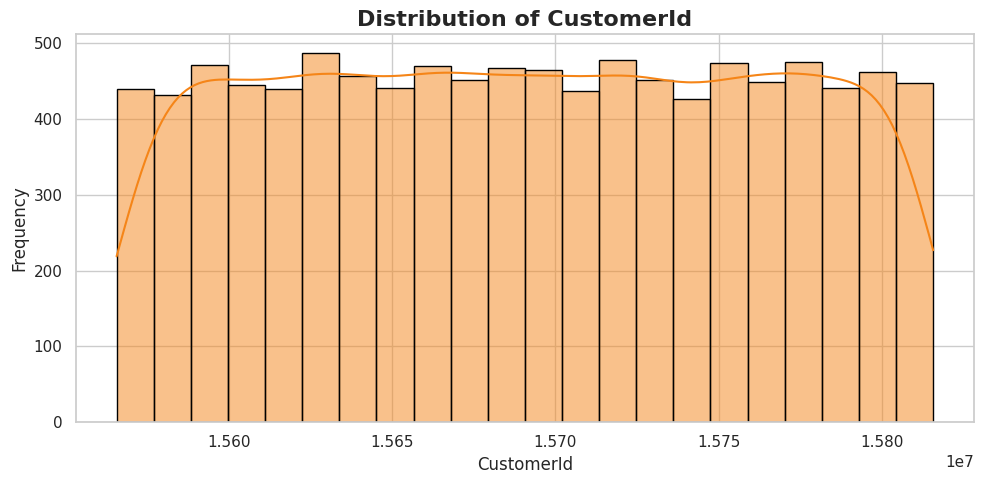

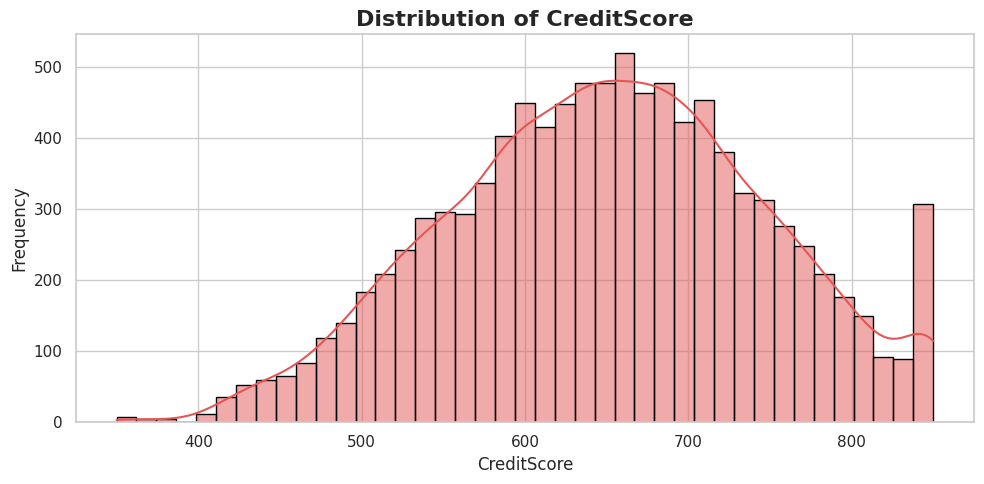

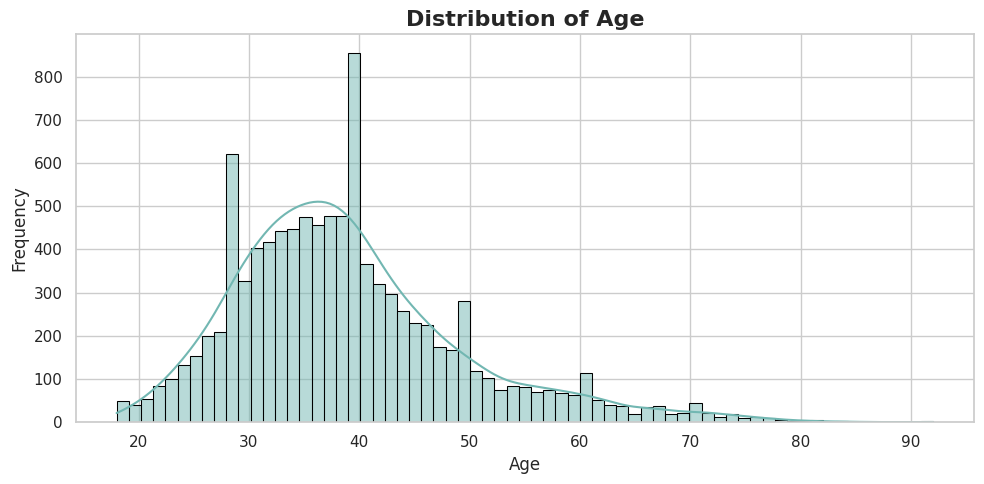

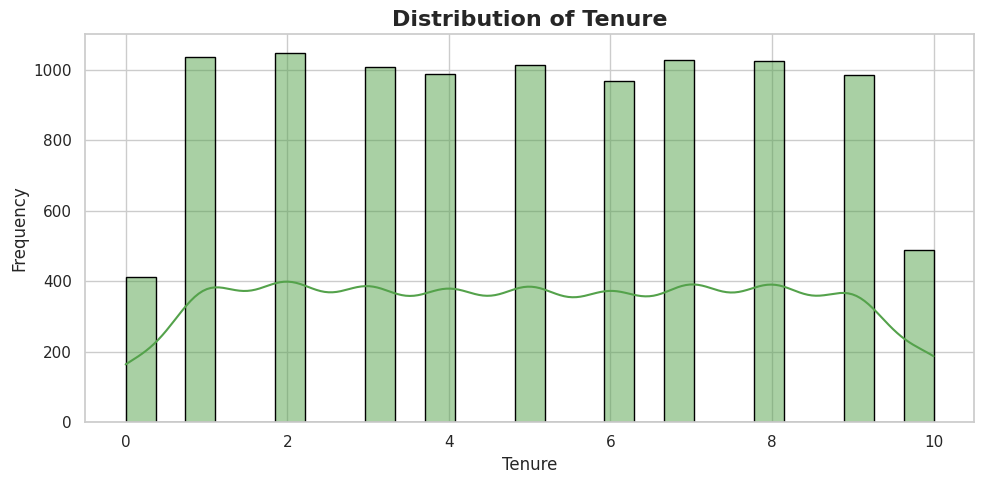

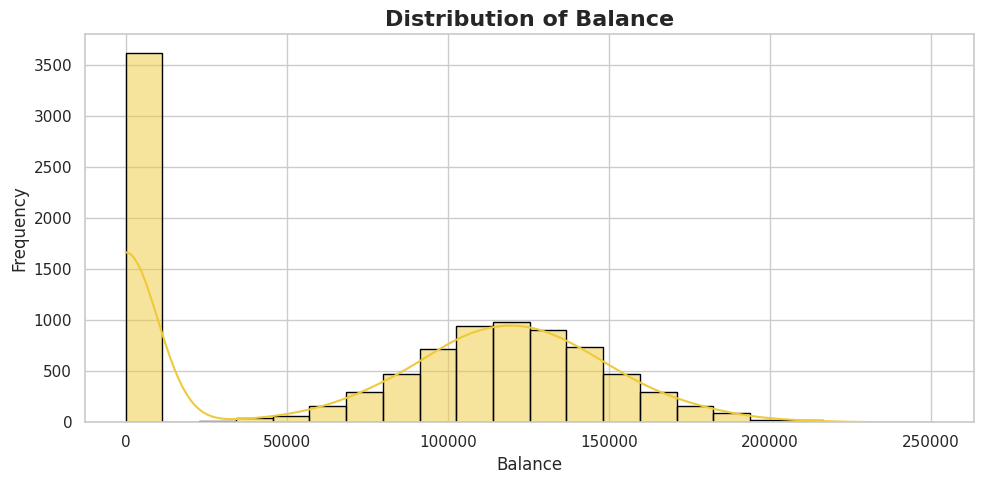

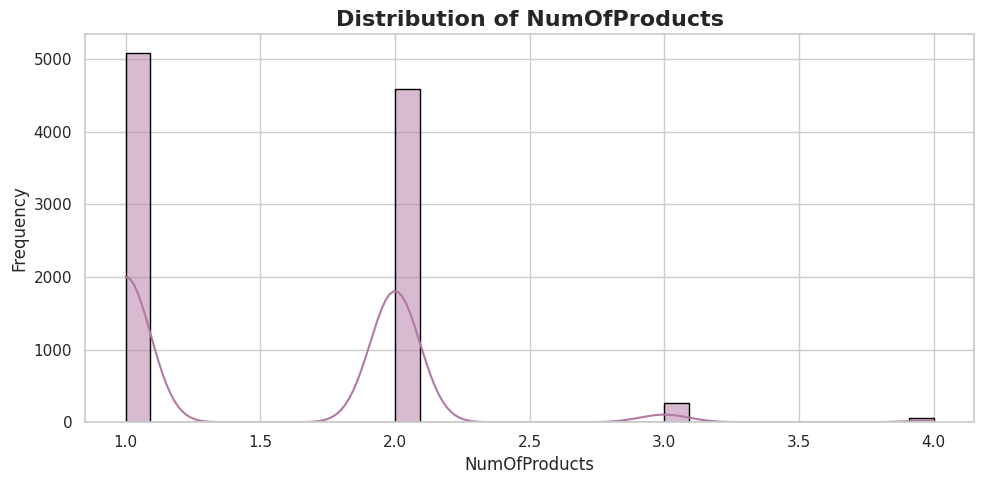

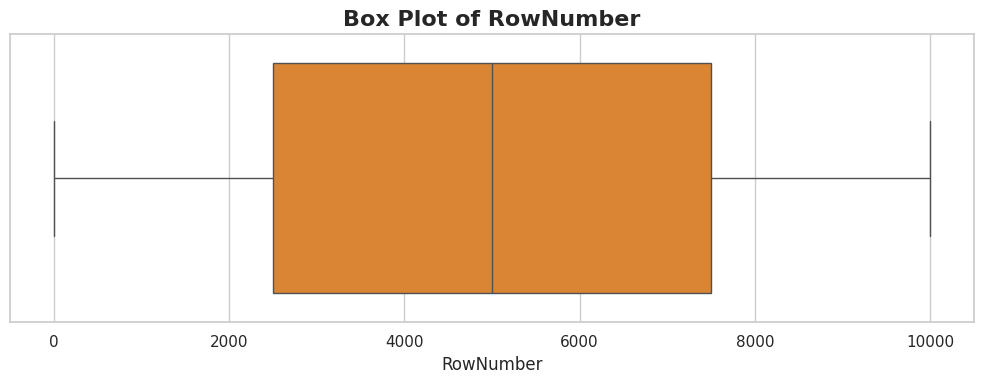

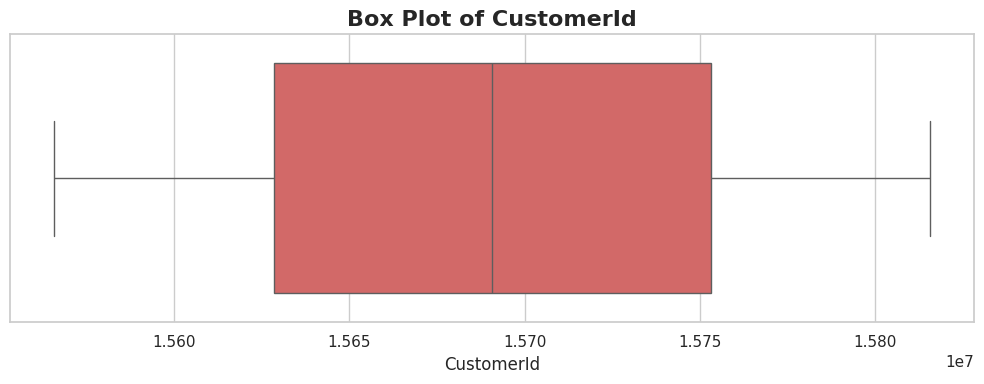

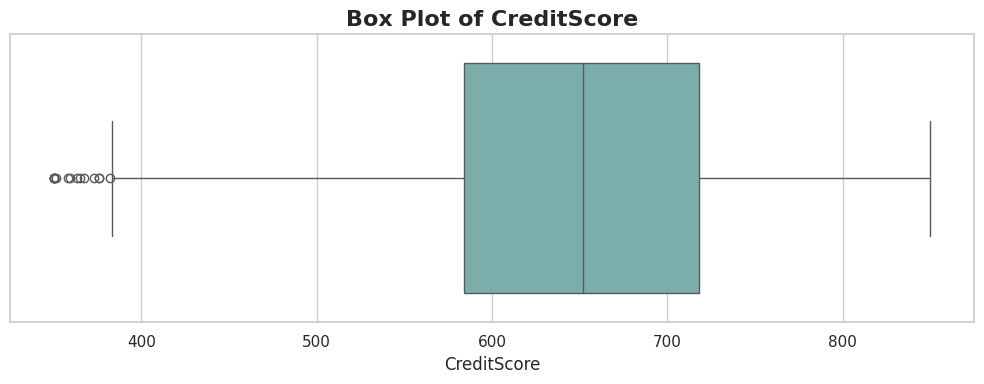

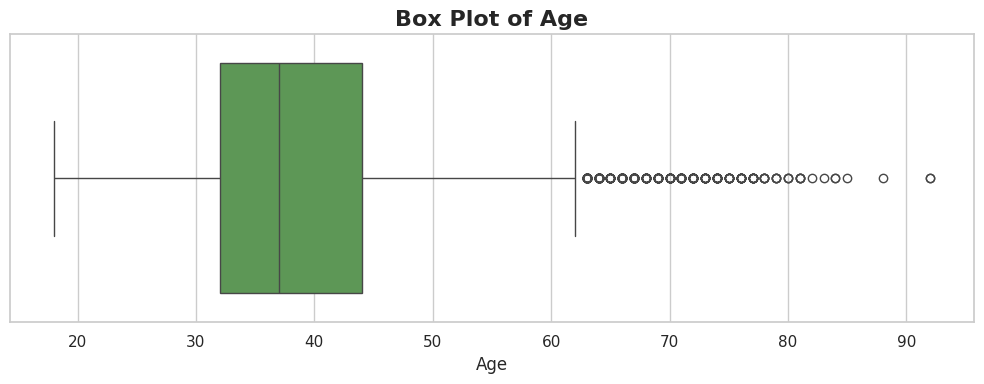

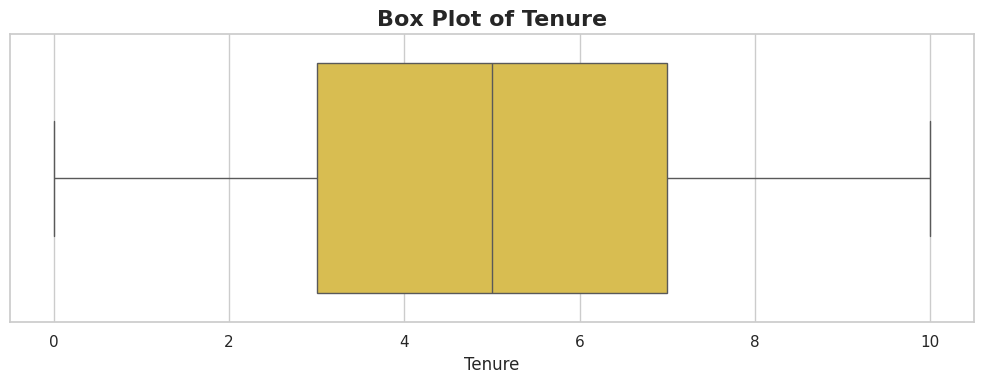

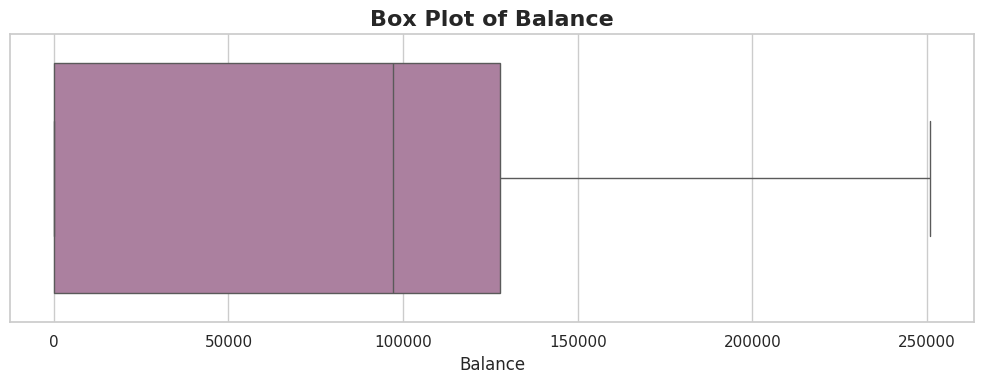

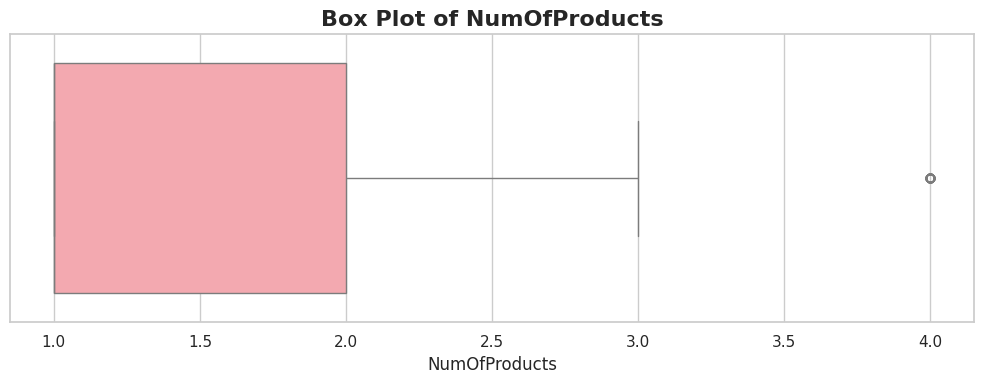

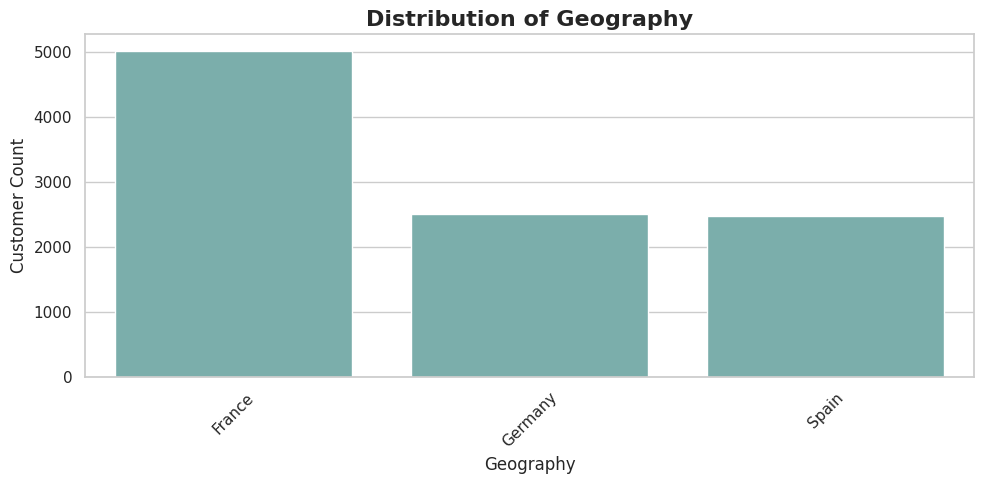

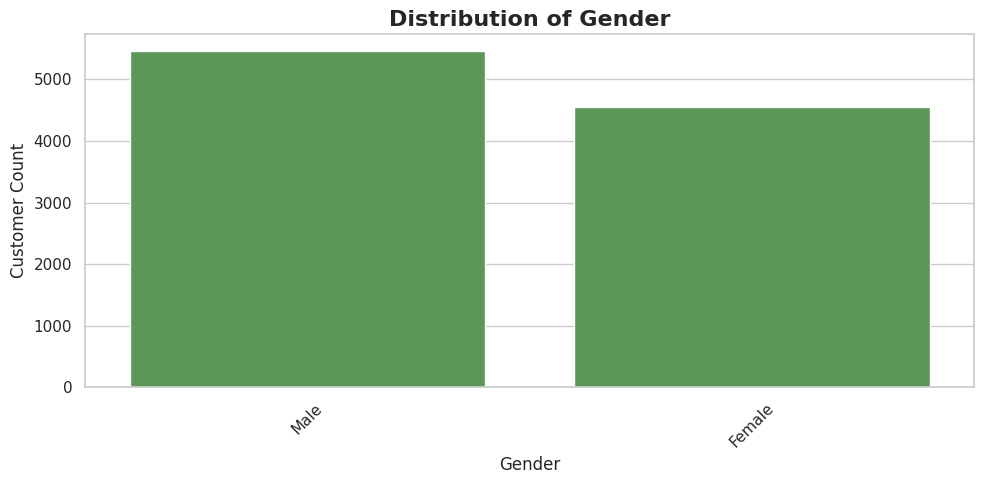

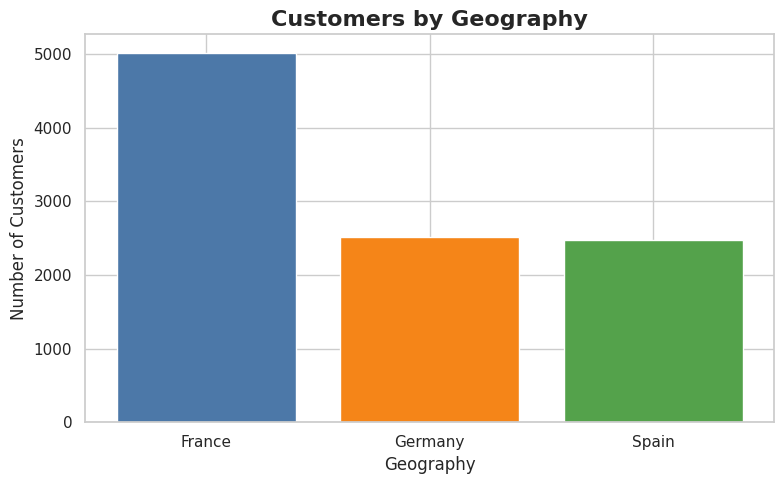

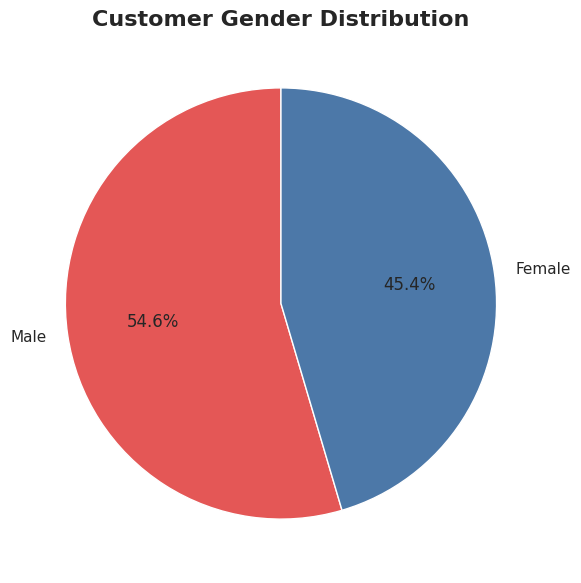

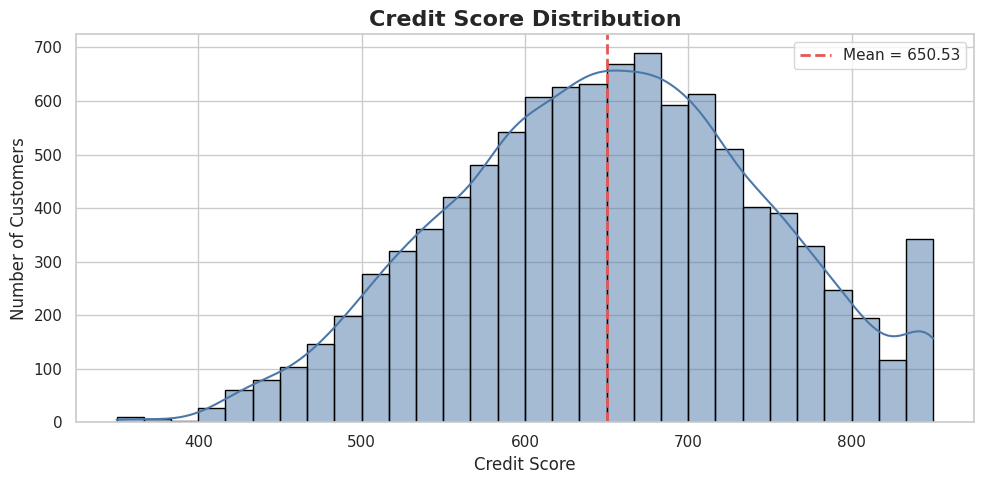

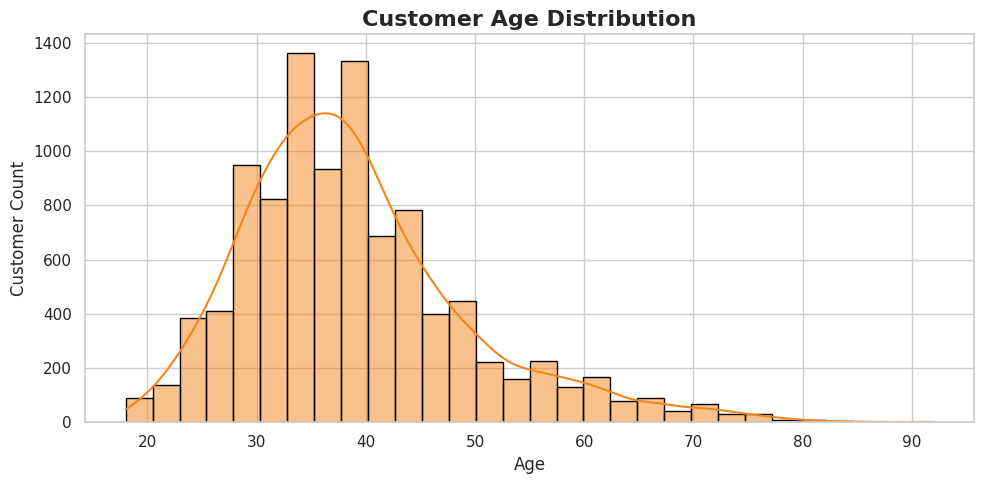

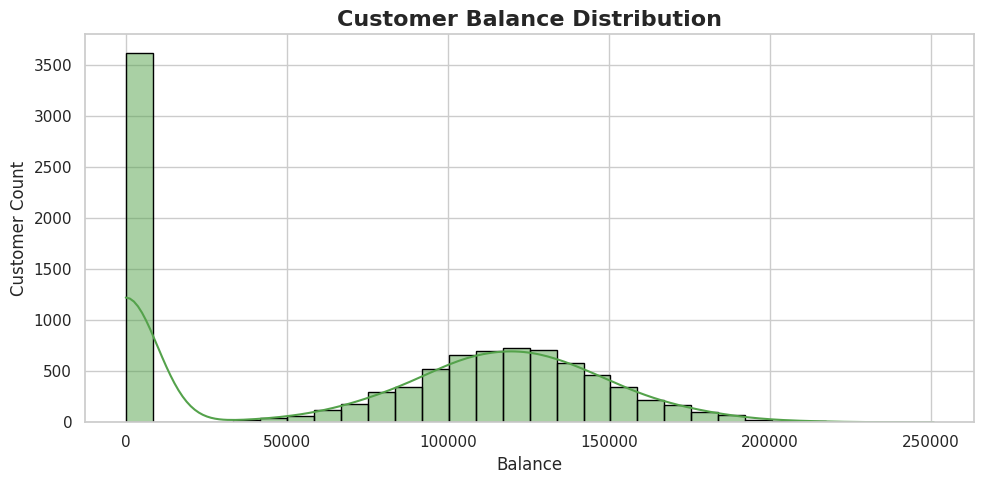

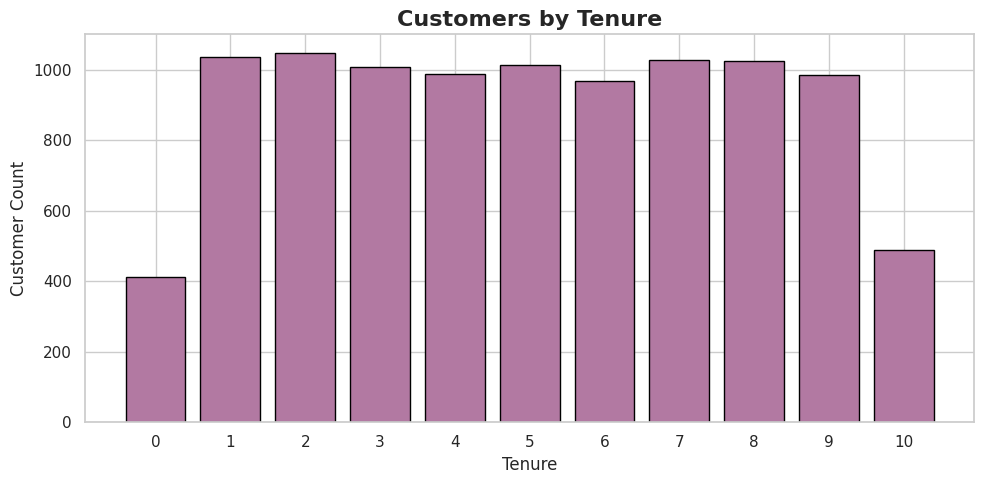

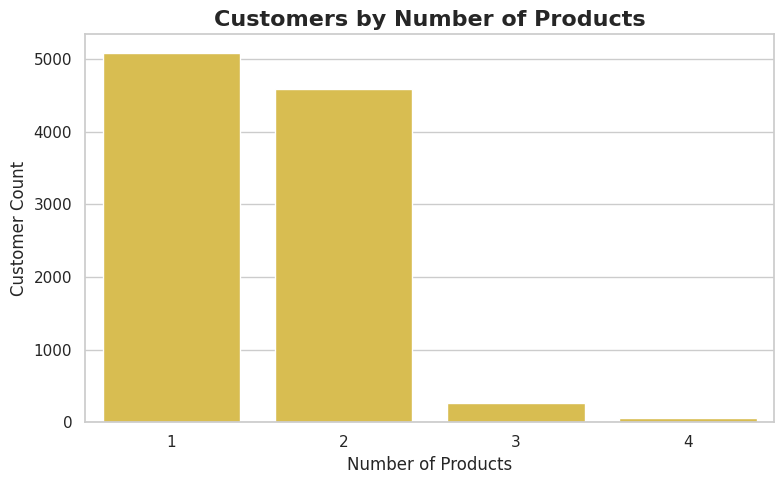

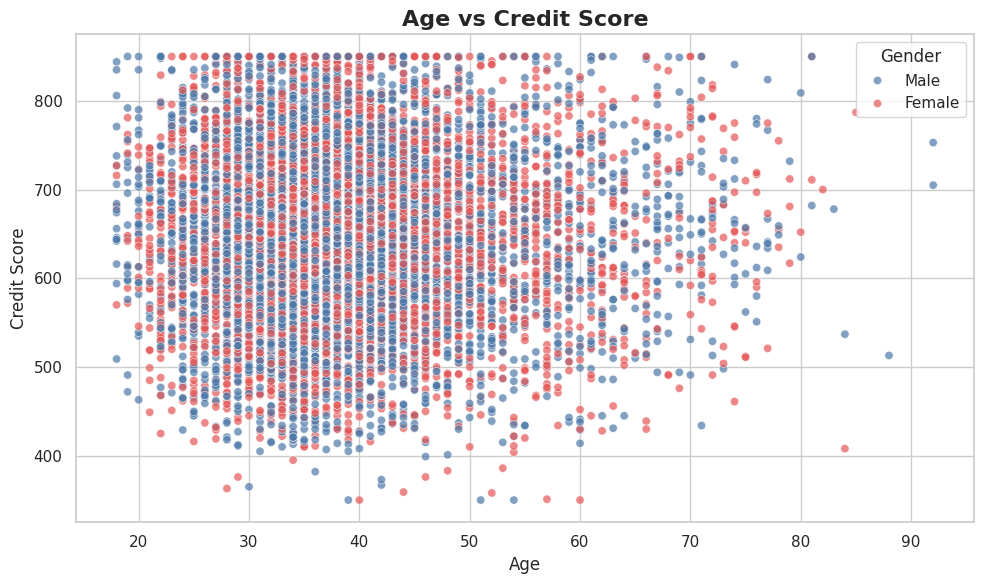

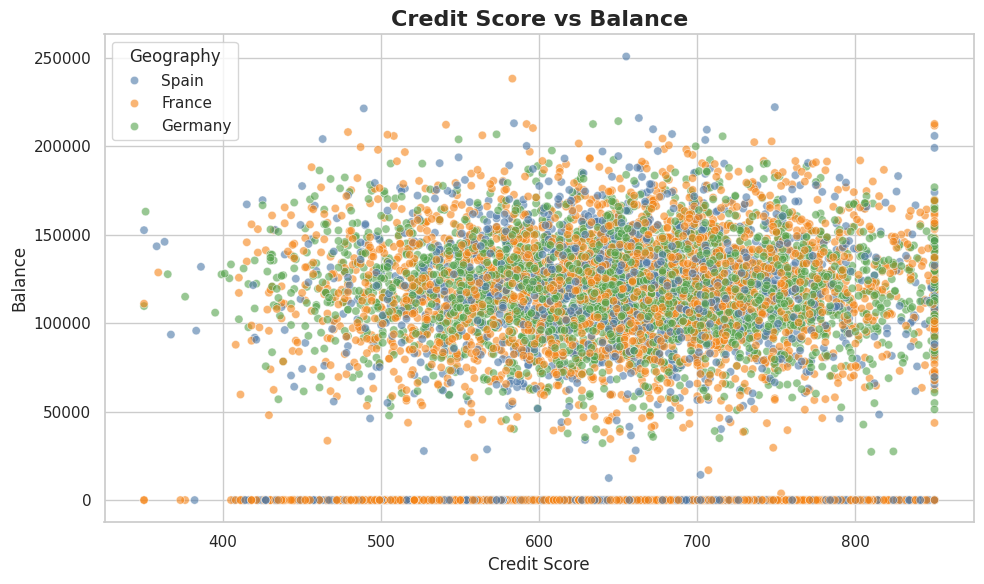

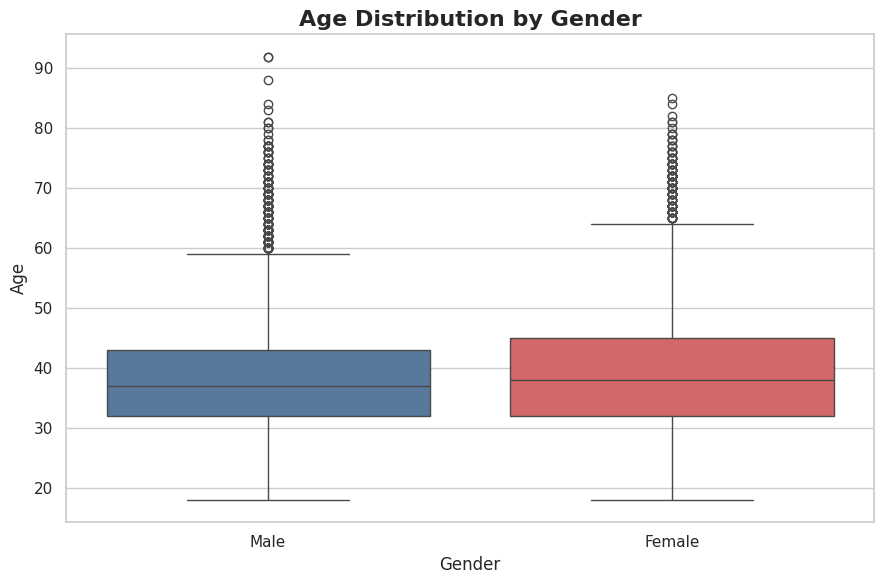

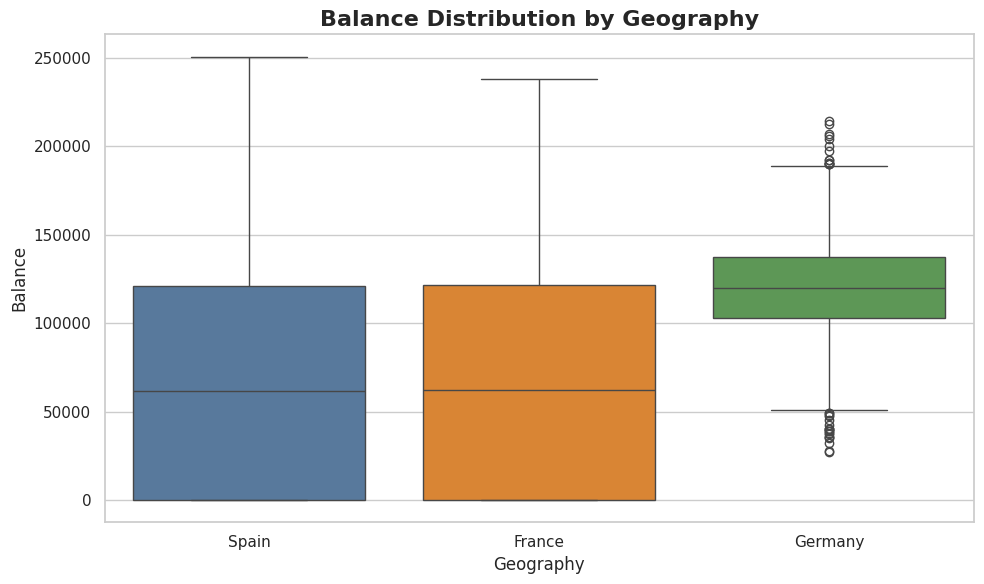

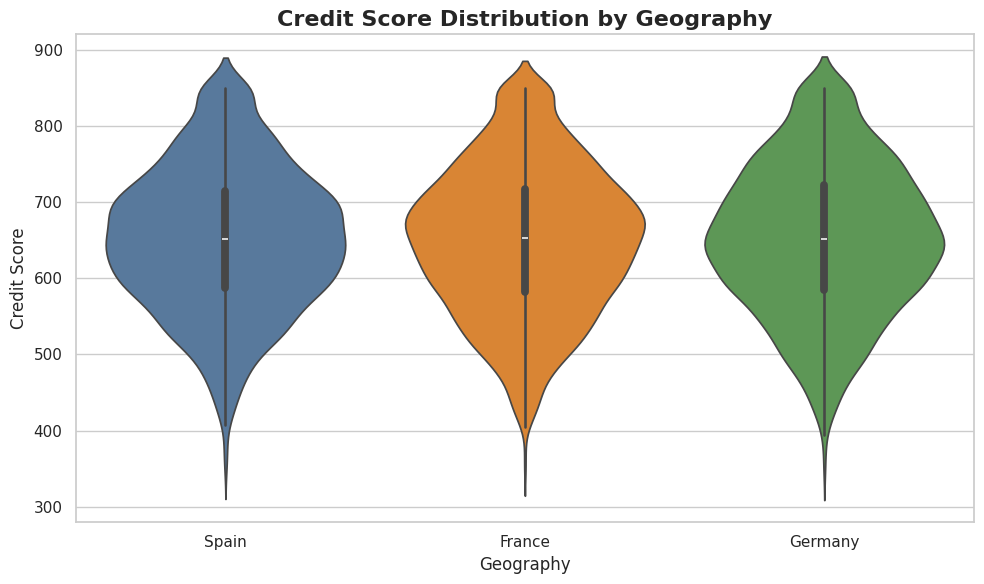

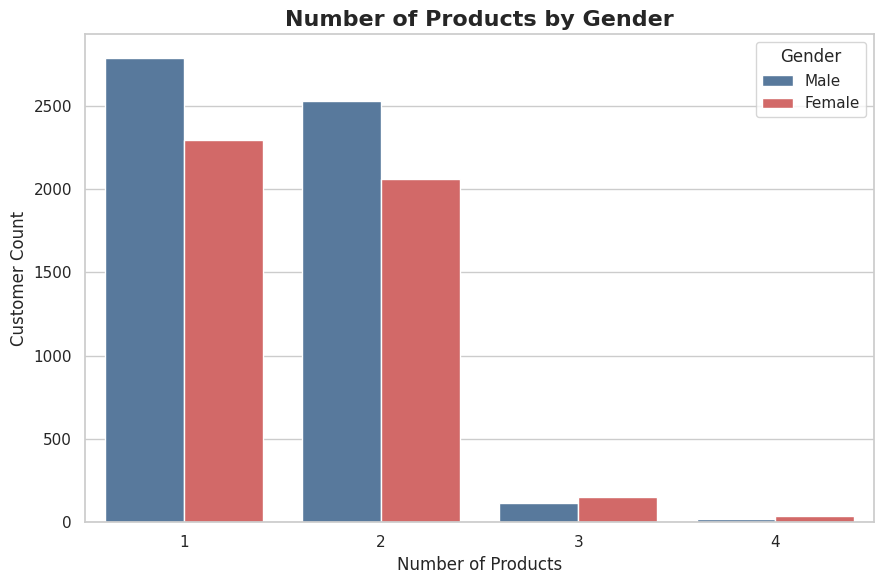

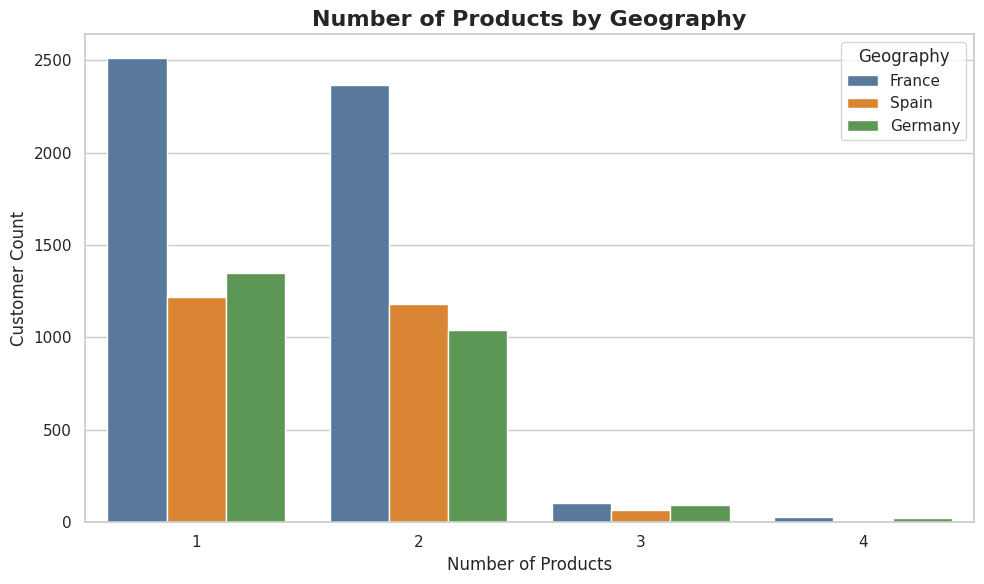

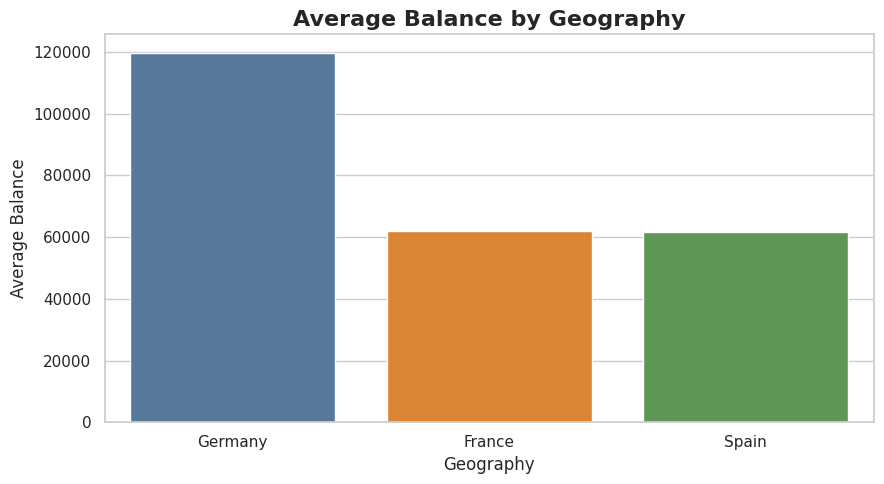

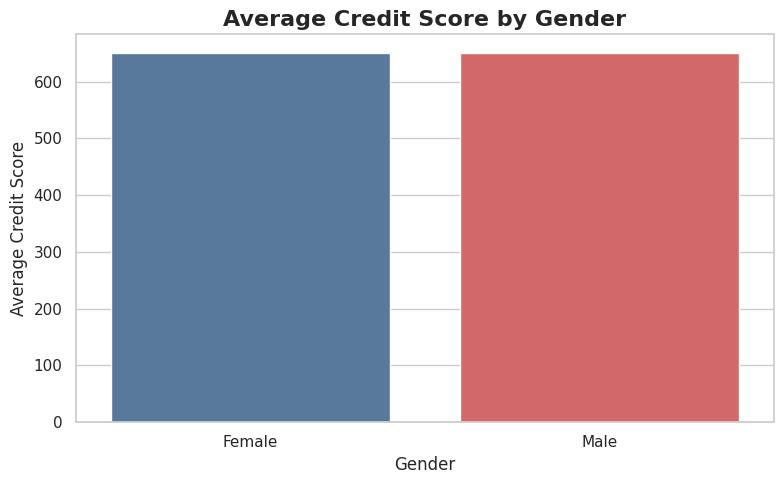

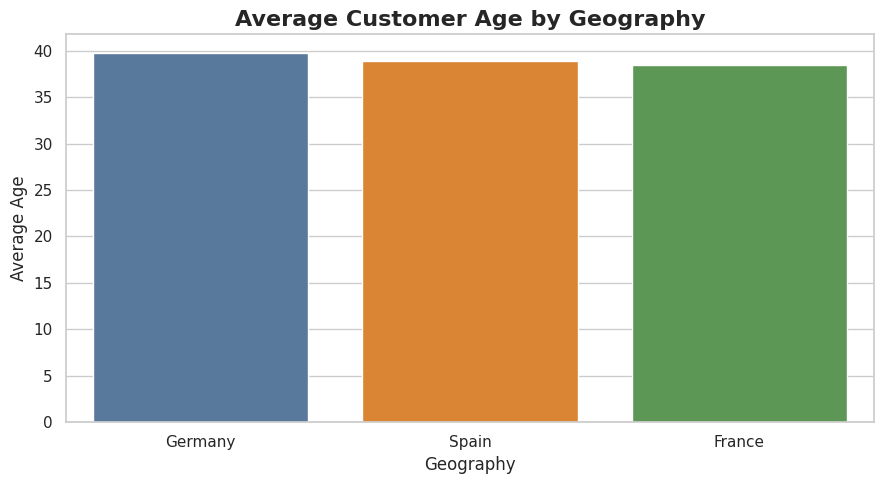

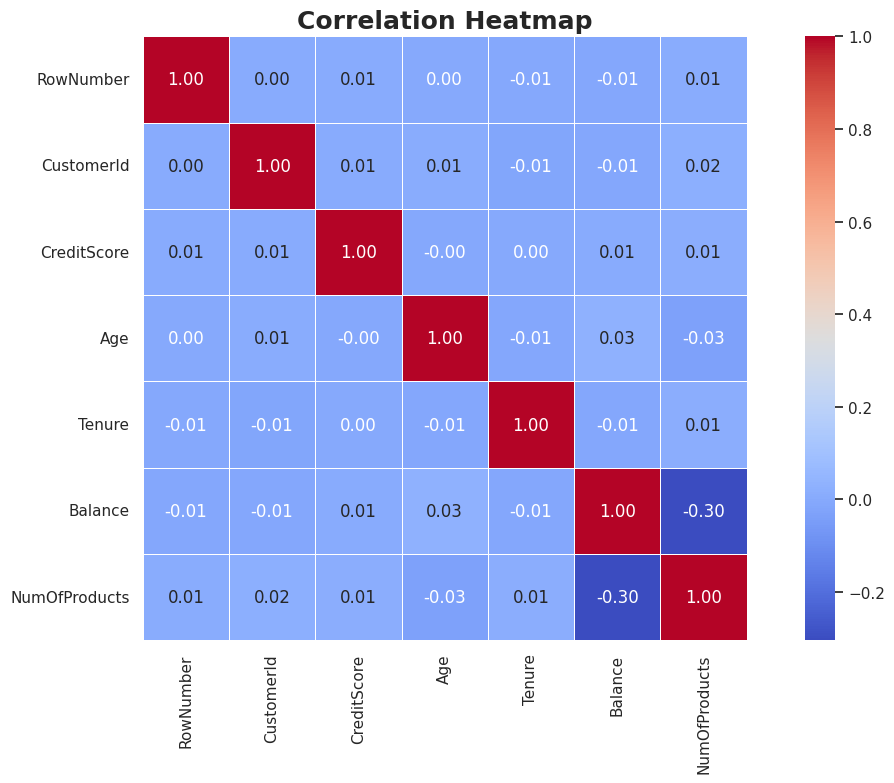

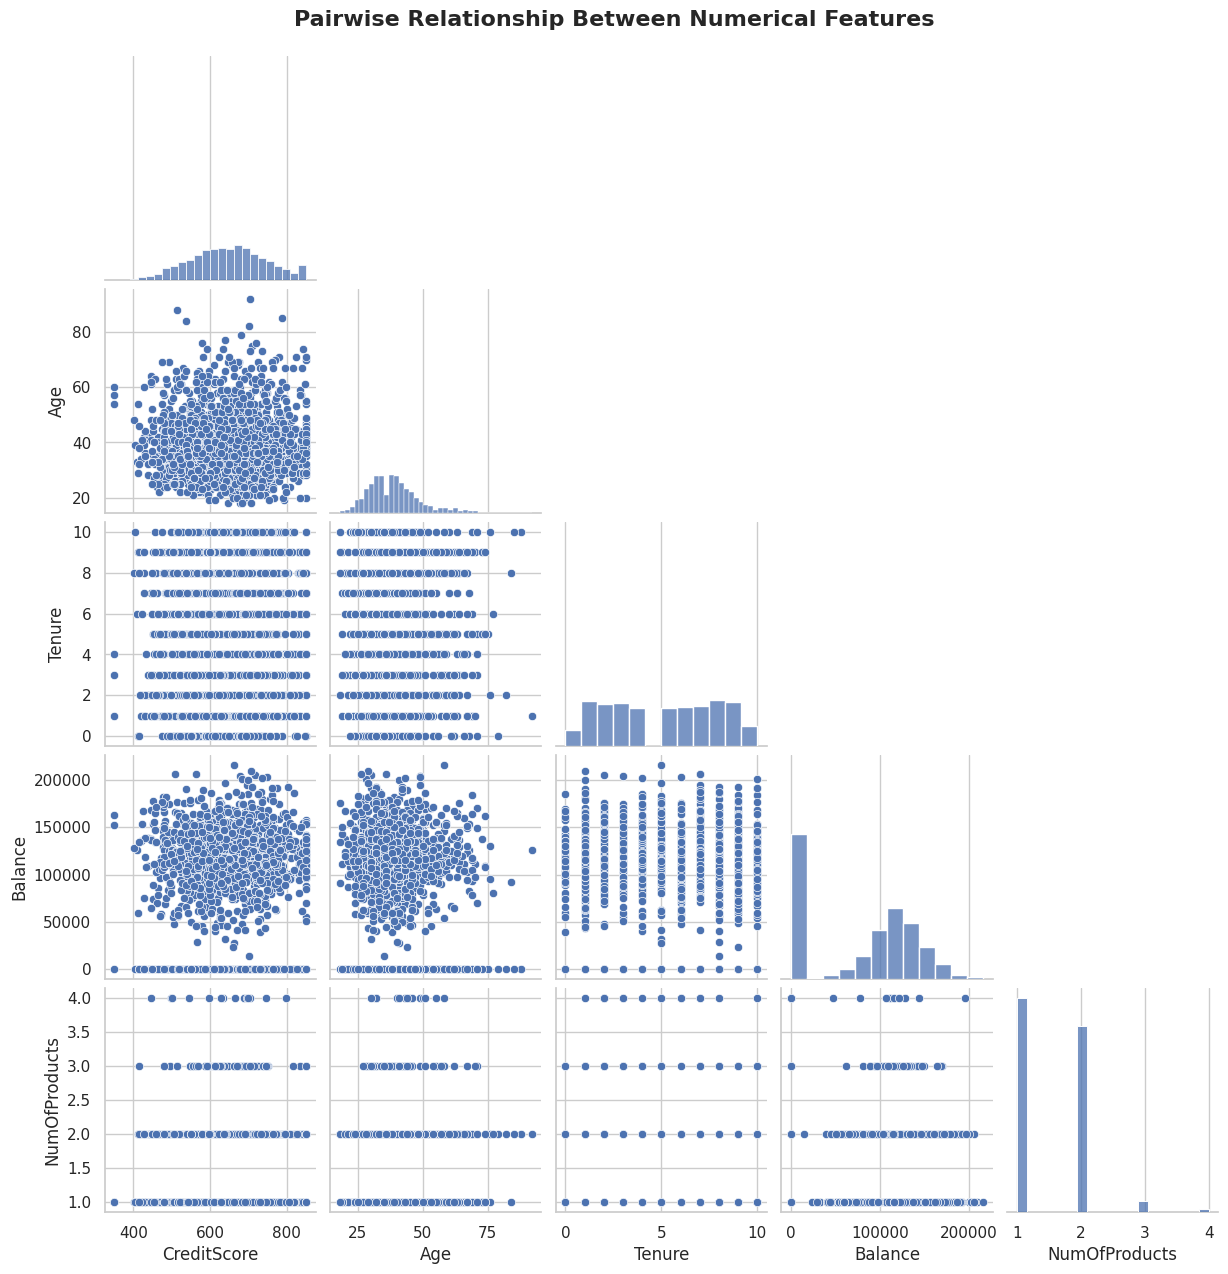

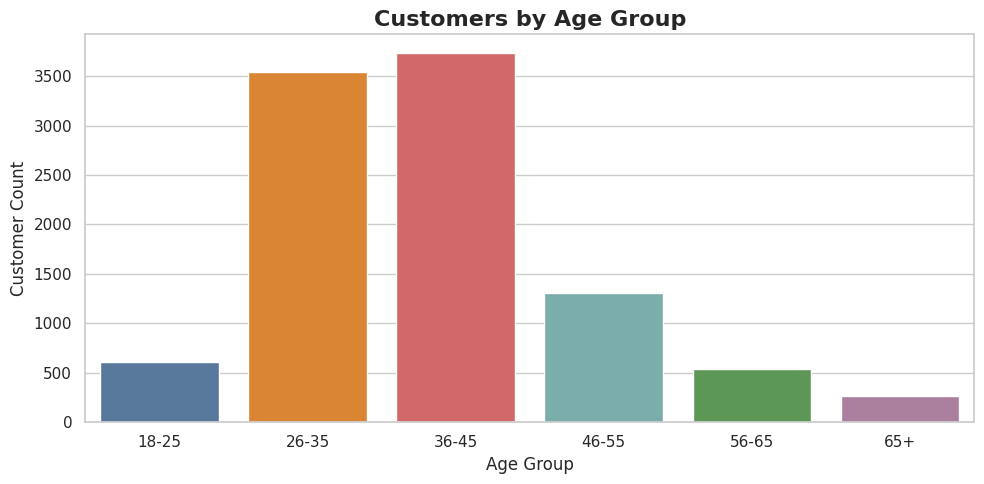

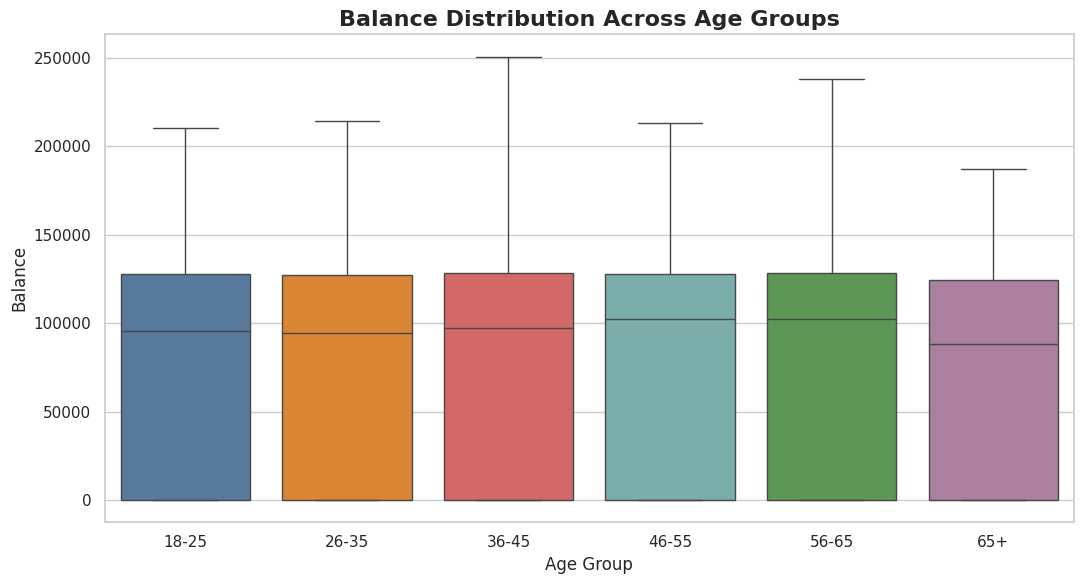

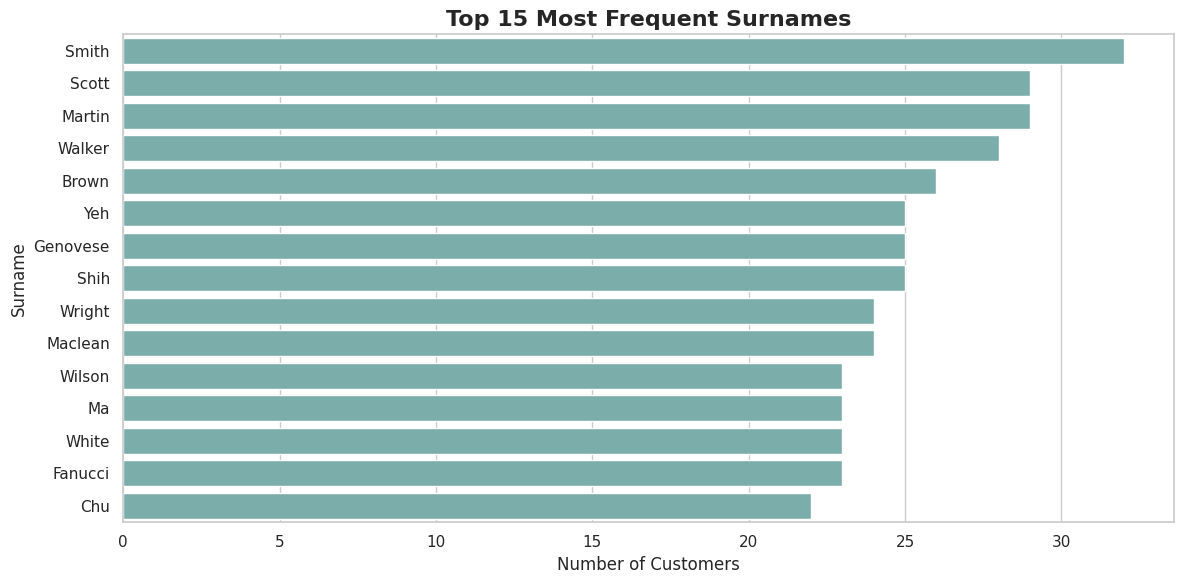

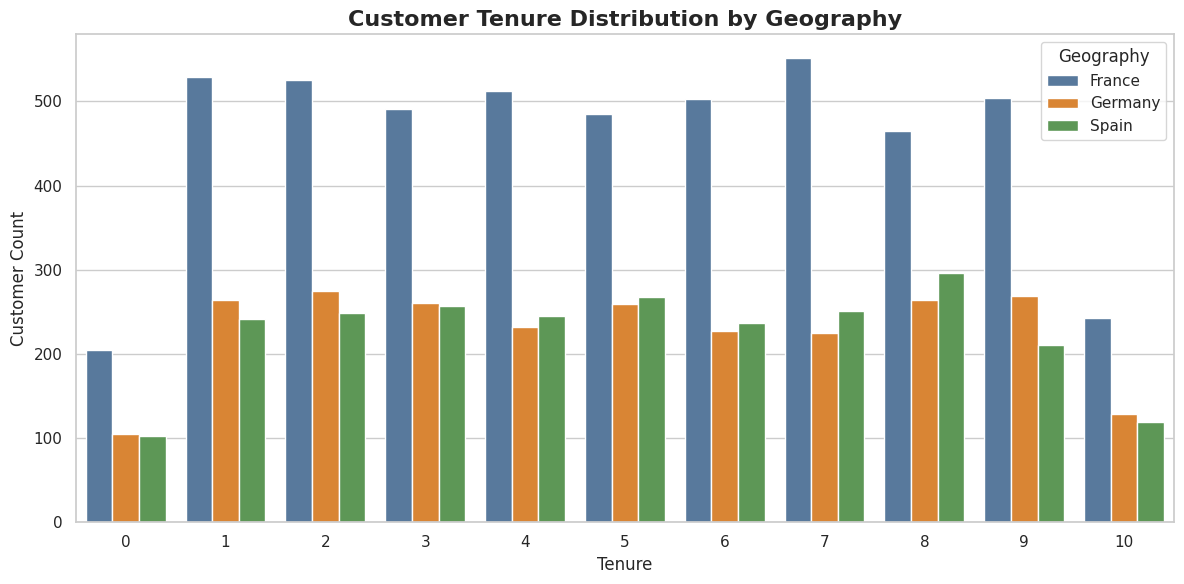

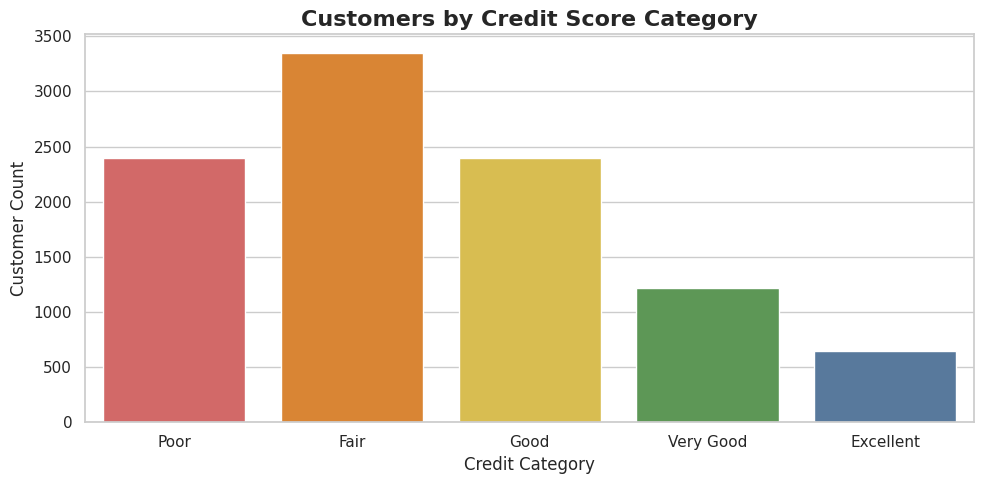

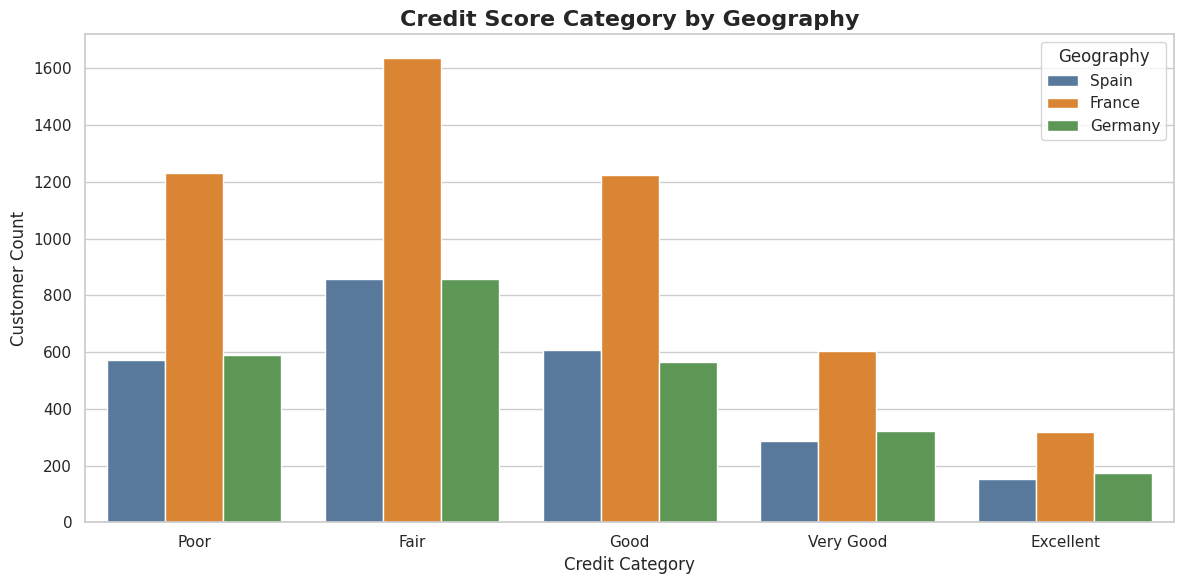


FINAL VISUALIZATION SUMMARY

Total Customers: 10000
Number of Geographies: 3
Number of Genders: 2
Average Age: 38.92
Average Credit Score: 650.53
Average Balance: 76485.89
Average Number of Products: 1.53

Visualization completed successfully.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Different colors
colors = [
    "#4C78A8", "#F58518", "#E45756", "#72B7B2",
    "#54A24B", "#EECA3B", "#B279A2", "#FF9DA6",
    "#9D755D", "#BAB0AC"
]

sns.set_theme(style="whitegrid")

# ============================================================
# 2. LOAD DATA
# ============================================================

# Change this according to your file
# df = pd.read_csv("your_file.csv")

# If df is already loaded, this line is not required
# print(df.head())

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

# ============================================================
# 3. BASIC INFORMATION
# ============================================================

print("\n" + "="*70)
print("DATASET INFORMATION")
print("="*70)

print("\nFirst 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())

print("\nDataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
display(df.describe(include="all").T)

# ============================================================
# 4. CHECK MISSING VALUES
# ============================================================

missing = df.isnull().sum()

missing = missing[missing > 0]

if len(missing) > 0:
    plt.figure(figsize=(10, 6))

    missing.sort_values(ascending=False).plot(
        kind="bar",
        color="#E45756"
    )

    plt.title("Missing Values by Column", fontsize=16, fontweight="bold")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    print("No missing values found.")

# ============================================================
# 5. DUPLICATE VALUES
# ============================================================

print("\nNumber of Duplicate Rows:", df.duplicated().sum())

# ============================================================
# 6. NUMERICAL AND CATEGORICAL COLUMNS
# ============================================================

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("\nNumerical Columns:")
print(numeric_cols)

print("\nCategorical Columns:")
print(categorical_cols)

# ============================================================
# 7. HISTOGRAMS FOR ALL NUMERICAL COLUMNS
# ============================================================

for i, col in enumerate(numeric_cols):

    plt.figure(figsize=(10, 5))

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        color=colors[i % len(colors)],
        edgecolor="black"
    )

    plt.title(
        f"Distribution of {col}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# ============================================================
# 8. BOXPLOTS FOR NUMERICAL COLUMNS
# ============================================================

for i, col in enumerate(numeric_cols):

    plt.figure(figsize=(10, 4))

    sns.boxplot(
        data=df,
        x=col,
        color=colors[(i + 1) % len(colors)]
    )

    plt.title(
        f"Box Plot of {col}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

# ============================================================
# 9. CATEGORICAL DISTRIBUTION
# ============================================================

for i, col in enumerate(categorical_cols):

    # Avoid extremely high-cardinality columns
    if df[col].nunique() <= 20:

        plt.figure(figsize=(10, 5))

        order = df[col].value_counts().index

        sns.countplot(
            data=df,
            x=col,
            order=order,
            color=colors[(i + 2) % len(colors)]
        )

        plt.title(
            f"Distribution of {col}",
            fontsize=16,
            fontweight="bold"
        )

        plt.xlabel(col)
        plt.ylabel("Customer Count")

        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

# ============================================================
# 10. GEOGRAPHY DISTRIBUTION
# ============================================================

if "Geography" in df.columns:

    geography_count = df["Geography"].value_counts()

    plt.figure(figsize=(8, 5))

    plt.bar(
        geography_count.index,
        geography_count.values,
        color=["#4C78A8", "#F58518", "#54A24B"]
    )

    plt.title(
        "Customers by Geography",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Geography")
    plt.ylabel("Number of Customers")

    plt.tight_layout()
    plt.show()

# ============================================================
# 11. GENDER DISTRIBUTION
# ============================================================

if "Gender" in df.columns:

    gender_count = df["Gender"].value_counts()

    plt.figure(figsize=(7, 7))

    plt.pie(
        gender_count.values,
        labels=gender_count.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=["#E45756", "#4C78A8"],
        wedgeprops={"edgecolor": "white"}
    )

    plt.title(
        "Customer Gender Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.show()

# ============================================================
# 12. CREDIT SCORE DISTRIBUTION
# ============================================================

if "CreditScore" in df.columns:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        df["CreditScore"],
        kde=True,
        bins=30,
        color="#4C78A8",
        edgecolor="black"
    )

    plt.axvline(
        df["CreditScore"].mean(),
        color="#E45756",
        linestyle="--",
        linewidth=2,
        label=f"Mean = {df['CreditScore'].mean():.2f}"
    )

    plt.title(
        "Credit Score Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Credit Score")
    plt.ylabel("Number of Customers")
    plt.legend()

    plt.tight_layout()
    plt.show()

# ============================================================
# 13. AGE DISTRIBUTION
# ============================================================

if "Age" in df.columns:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        data=df,
        x="Age",
        bins=30,
        kde=True,
        color="#F58518",
        edgecolor="black"
    )

    plt.title(
        "Customer Age Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Age")
    plt.ylabel("Customer Count")

    plt.tight_layout()
    plt.show()

# ============================================================
# 14. BALANCE DISTRIBUTION
# ============================================================

if "Balance" in df.columns:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        data=df,
        x="Balance",
        bins=30,
        kde=True,
        color="#54A24B",
        edgecolor="black"
    )

    plt.title(
        "Customer Balance Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Balance")
    plt.ylabel("Customer Count")

    plt.tight_layout()
    plt.show()

# ============================================================
# 15. TENURE DISTRIBUTION
# ============================================================

if "Tenure" in df.columns:

    tenure_count = df["Tenure"].value_counts().sort_index()

    plt.figure(figsize=(10, 5))

    plt.bar(
        tenure_count.index.astype(str),
        tenure_count.values,
        color="#B279A2",
        edgecolor="black"
    )

    plt.title(
        "Customers by Tenure",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Tenure")
    plt.ylabel("Customer Count")

    plt.tight_layout()
    plt.show()

# ============================================================
# 16. NUMBER OF PRODUCTS
# ============================================================

if "NumOfProducts" in df.columns:

    product_count = df["NumOfProducts"].value_counts().sort_index()

    plt.figure(figsize=(8, 5))

    sns.barplot(
        x=product_count.index,
        y=product_count.values,
        color="#EECA3B"
    )

    plt.title(
        "Customers by Number of Products",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Number of Products")
    plt.ylabel("Customer Count")

    plt.tight_layout()
    plt.show()

# ============================================================
# 17. CREDIT SCORE VS AGE
# ============================================================

if "CreditScore" in df.columns and "Age" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x="Age",
        y="CreditScore",
        hue="Gender" if "Gender" in df.columns else None,
        palette=["#4C78A8", "#E45756"],
        alpha=0.7
    )

    plt.title(
        "Age vs Credit Score",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Age")
    plt.ylabel("Credit Score")

    plt.tight_layout()
    plt.show()

# ============================================================
# 18. BALANCE VS CREDIT SCORE
# ============================================================

if "Balance" in df.columns and "CreditScore" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x="CreditScore",
        y="Balance",
        hue="Geography" if "Geography" in df.columns else None,
        palette=["#4C78A8", "#F58518", "#54A24B"],
        alpha=0.6
    )

    plt.title(
        "Credit Score vs Balance",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Credit Score")
    plt.ylabel("Balance")

    plt.tight_layout()
    plt.show()

# ============================================================
# 19. AGE BY GENDER
# ============================================================

if "Age" in df.columns and "Gender" in df.columns:

    plt.figure(figsize=(9, 6))

    sns.boxplot(
        data=df,
        x="Gender",
        y="Age",
        palette=["#4C78A8", "#E45756"]
    )

    plt.title(
        "Age Distribution by Gender",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Gender")
    plt.ylabel("Age")

    plt.tight_layout()
    plt.show()

# ============================================================
# 20. BALANCE BY GEOGRAPHY
# ============================================================

if "Balance" in df.columns and "Geography" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=df,
        x="Geography",
        y="Balance",
        palette=["#4C78A8", "#F58518", "#54A24B"]
    )

    plt.title(
        "Balance Distribution by Geography",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Geography")
    plt.ylabel("Balance")

    plt.tight_layout()
    plt.show()

# ============================================================
# 21. CREDIT SCORE BY GEOGRAPHY
# ============================================================

if "CreditScore" in df.columns and "Geography" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.violinplot(
        data=df,
        x="Geography",
        y="CreditScore",
        palette=["#4C78A8", "#F58518", "#54A24B"]
    )

    plt.title(
        "Credit Score Distribution by Geography",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Geography")
    plt.ylabel("Credit Score")

    plt.tight_layout()
    plt.show()

# ============================================================
# 22. PRODUCTS BY GENDER
# ============================================================

if "NumOfProducts" in df.columns and "Gender" in df.columns:

    plt.figure(figsize=(9, 6))

    sns.countplot(
        data=df,
        x="NumOfProducts",
        hue="Gender",
        palette=["#4C78A8", "#E45756"]
    )

    plt.title(
        "Number of Products by Gender",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Number of Products")
    plt.ylabel("Customer Count")

    plt.tight_layout()
    plt.show()

# ============================================================
# 23. PRODUCTS BY GEOGRAPHY
# ============================================================

if "NumOfProducts" in df.columns and "Geography" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=df,
        x="NumOfProducts",
        hue="Geography",
        palette=["#4C78A8", "#F58518", "#54A24B"]
    )

    plt.title(
        "Number of Products by Geography",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Number of Products")
    plt.ylabel("Customer Count")

    plt.tight_layout()
    plt.show()

# ============================================================
# 24. AVERAGE BALANCE BY GEOGRAPHY
# ============================================================

if "Balance" in df.columns and "Geography" in df.columns:

    avg_balance = (
        df.groupby("Geography")["Balance"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(9, 5))

    sns.barplot(
        x=avg_balance.index,
        y=avg_balance.values,
        palette=["#4C78A8", "#F58518", "#54A24B"]
    )

    plt.title(
        "Average Balance by Geography",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Geography")
    plt.ylabel("Average Balance")

    plt.tight_layout()
    plt.show()

# ============================================================
# 25. AVERAGE CREDIT SCORE BY GENDER
# ============================================================

if "CreditScore" in df.columns and "Gender" in df.columns:

    avg_credit = (
        df.groupby("Gender")["CreditScore"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(8, 5))

    sns.barplot(
        x=avg_credit.index,
        y=avg_credit.values,
        palette=["#4C78A8", "#E45756"]
    )

    plt.title(
        "Average Credit Score by Gender",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Gender")
    plt.ylabel("Average Credit Score")

    plt.tight_layout()
    plt.show()

# ============================================================
# 26. AVERAGE AGE BY GEOGRAPHY
# ============================================================

if "Age" in df.columns and "Geography" in df.columns:

    avg_age = (
        df.groupby("Geography")["Age"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(9, 5))

    sns.barplot(
        x=avg_age.index,
        y=avg_age.values,
        palette=["#4C78A8", "#F58518", "#54A24B"]
    )

    plt.title(
        "Average Customer Age by Geography",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Geography")
    plt.ylabel("Average Age")

    plt.tight_layout()
    plt.show()

# ============================================================
# 27. CORRELATION HEATMAP
# ============================================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 8))

correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Heatmap",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# ============================================================
# 28. PAIRPLOT
# ============================================================

pair_columns = [
    col for col in [
        "CreditScore",
        "Age",
        "Tenure",
        "Balance",
        "NumOfProducts"
    ]
    if col in df.columns
]

if len(pair_columns) >= 2:

    pair_df = df[pair_columns].dropna()

    # Limit rows for faster visualization
    if len(pair_df) > 2000:
        pair_df = pair_df.sample(
            2000,
            random_state=42
        )

    sns.pairplot(
        pair_df,
        diag_kind="hist",
        corner=True
    )

    plt.suptitle(
        "Pairwise Relationship Between Numerical Features",
        y=1.02,
        fontsize=16,
        fontweight="bold"
    )

    plt.show()

# ============================================================
# 29. CUSTOMER AGE GROUPS
# ============================================================

if "Age" in df.columns:

    bins = [0, 25, 35, 45, 55, 65, 100]

    labels = [
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "65+"
    ]

    df["Age_Group"] = pd.cut(
        df["Age"],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    age_group_count = df["Age_Group"].value_counts().sort_index()

    plt.figure(figsize=(10, 5))

    sns.barplot(
        x=age_group_count.index,
        y=age_group_count.values,
        palette=[
            "#4C78A8",
            "#F58518",
            "#E45756",
            "#72B7B2",
            "#54A24B",
            "#B279A2"
        ]
    )

    plt.title(
        "Customers by Age Group",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Age Group")
    plt.ylabel("Customer Count")

    plt.tight_layout()
    plt.show()

# ============================================================
# 30. BALANCE BY AGE GROUP
# ============================================================

if "Age_Group" in df.columns and "Balance" in df.columns:

    plt.figure(figsize=(11, 6))

    sns.boxplot(
        data=df,
        x="Age_Group",
        y="Balance",
        palette=[
            "#4C78A8",
            "#F58518",
            "#E45756",
            "#72B7B2",
            "#54A24B",
            "#B279A2"
        ]
    )

    plt.title(
        "Balance Distribution Across Age Groups",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Age Group")
    plt.ylabel("Balance")

    plt.tight_layout()
    plt.show()

# ============================================================
# 31. TOP SURNAMES
# ============================================================

if "Surname" in df.columns:

    top_surnames = df["Surname"].value_counts().head(15)

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x=top_surnames.values,
        y=top_surnames.index,
        color="#72B7B2"
    )

    plt.title(
        "Top 15 Most Frequent Surnames",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Number of Customers")
    plt.ylabel("Surname")

    plt.tight_layout()
    plt.show()

# ============================================================
# 32. CUSTOMER DISTRIBUTION BY TENURE AND GEOGRAPHY
# ============================================================

if "Tenure" in df.columns and "Geography" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.countplot(
        data=df,
        x="Tenure",
        hue="Geography",
        palette=["#4C78A8", "#F58518", "#54A24B"]
    )

    plt.title(
        "Customer Tenure Distribution by Geography",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Tenure")
    plt.ylabel("Customer Count")

    plt.tight_layout()
    plt.show()

# ============================================================
# 33. CREDIT SCORE CATEGORY
# ============================================================

if "CreditScore" in df.columns:

    credit_bins = [0, 580, 670, 740, 800, 1000]

    credit_labels = [
        "Poor",
        "Fair",
        "Good",
        "Very Good",
        "Excellent"
    ]

    df["Credit_Category"] = pd.cut(
        df["CreditScore"],
        bins=credit_bins,
        labels=credit_labels,
        include_lowest=True
    )

    credit_category = (
        df["Credit_Category"]
        .value_counts()
        .reindex(credit_labels)
    )

    plt.figure(figsize=(10, 5))

    sns.barplot(
        x=credit_category.index,
        y=credit_category.values,
        palette=[
            "#E45756",
            "#F58518",
            "#EECA3B",
            "#54A24B",
            "#4C78A8"
        ]
    )

    plt.title(
        "Customers by Credit Score Category",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Credit Category")
    plt.ylabel("Customer Count")

    plt.tight_layout()
    plt.show()

# ============================================================
# 34. CREDIT CATEGORY BY GEOGRAPHY
# ============================================================

if "Credit_Category" in df.columns and "Geography" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.countplot(
        data=df,
        x="Credit_Category",
        hue="Geography",
        palette=["#4C78A8", "#F58518", "#54A24B"]
    )

    plt.title(
        "Credit Score Category by Geography",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Credit Category")
    plt.ylabel("Customer Count")

    plt.tight_layout()
    plt.show()

# ============================================================
# 35. FINAL DATA SUMMARY
# ============================================================

print("\n" + "="*70)
print("FINAL VISUALIZATION SUMMARY")
print("="*70)

print("\nTotal Customers:", len(df))

if "Geography" in df.columns:
    print("Number of Geographies:", df["Geography"].nunique())

if "Gender" in df.columns:
    print("Number of Genders:", df["Gender"].nunique())

if "Age" in df.columns:
    print("Average Age:", round(df["Age"].mean(), 2))

if "CreditScore" in df.columns:
    print("Average Credit Score:", round(df["CreditScore"].mean(), 2))

if "Balance" in df.columns:
    print("Average Balance:", round(df["Balance"].mean(), 2))

if "NumOfProducts" in df.columns:
    print("Average Number of Products:",
          round(df["NumOfProducts"].mean(), 2))

print("\nVisualization completed successfully.")

## Feature engineering

DATASET INFORMATION

Shape:
(10000, 12)

Columns:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'Age_Group', 'Credit_Category']

First 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,Age_Group,Credit_Category
0,1,15574012,Chu,645,Spain,Male,44,8,113755.78,2,36-45,Fair
1,2,15592531,Bartlett,822,France,Male,50,7,0.00,2,46-55,Excellent
2,3,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,26-35,Poor
3,4,15792365,He,501,France,Male,44,4,142051.07,2,36-45,Poor
4,5,15592389,H?,684,France,Male,27,2,134603.88,1,26-35,Good



All required columns are available.

FEATURES AND TARGET

Features:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'Age_Group', 'Credit_Category']

Target:
NumOfProducts

Target Distribution:
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

Target Distribution After Checking:
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

Original Target Classes:
[1 2 3 4]

Encoded Target Classes:
[0 1 2 3]

Numerical Features:
['CreditScore', 'Age', 'Tenure', 'Balance']

Categorical Features:
['Geography', 'Gender', 'Age_Group', 'Credit_Category']

TRAIN TEST SPLIT
X_train: (8000, 8)
X_test : (2000, 8)
y_train: (8000,)
y_test : (2000,)

TRAINING: Logistic Regression
Accuracy : 0.6785
Precision: 0.6563
Recall   : 0.6785
F1 Score : 0.6666
ROC AUC  : 0.7236

TRAINING: Decision Tree
Accuracy : 0.6800
Precision: 0.6634
Recall   : 0.6800
F1 Score : 0.6647
ROC AUC  : 0.7191

TRAINING: Random Forest
Accuracy : 0.6835
Precis

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
7,CatBoost,68.15%,66.00%,68.15%,66.85%,0.7336
2,Random Forest,68.35%,66.39%,68.35%,66.93%,0.7304
3,Gradient Boosting,67.75%,65.82%,67.75%,66.57%,0.7268
0,Logistic Regression,67.85%,65.63%,67.85%,66.66%,0.7236
5,XGBoost,66.85%,64.67%,66.85%,65.64%,0.7206
1,Decision Tree,68.00%,66.34%,68.00%,66.47%,0.7191
6,LightGBM,67.30%,65.13%,67.30%,66.13%,0.7164
4,KNN,66.00%,63.83%,66.00%,64.84%,0.7003


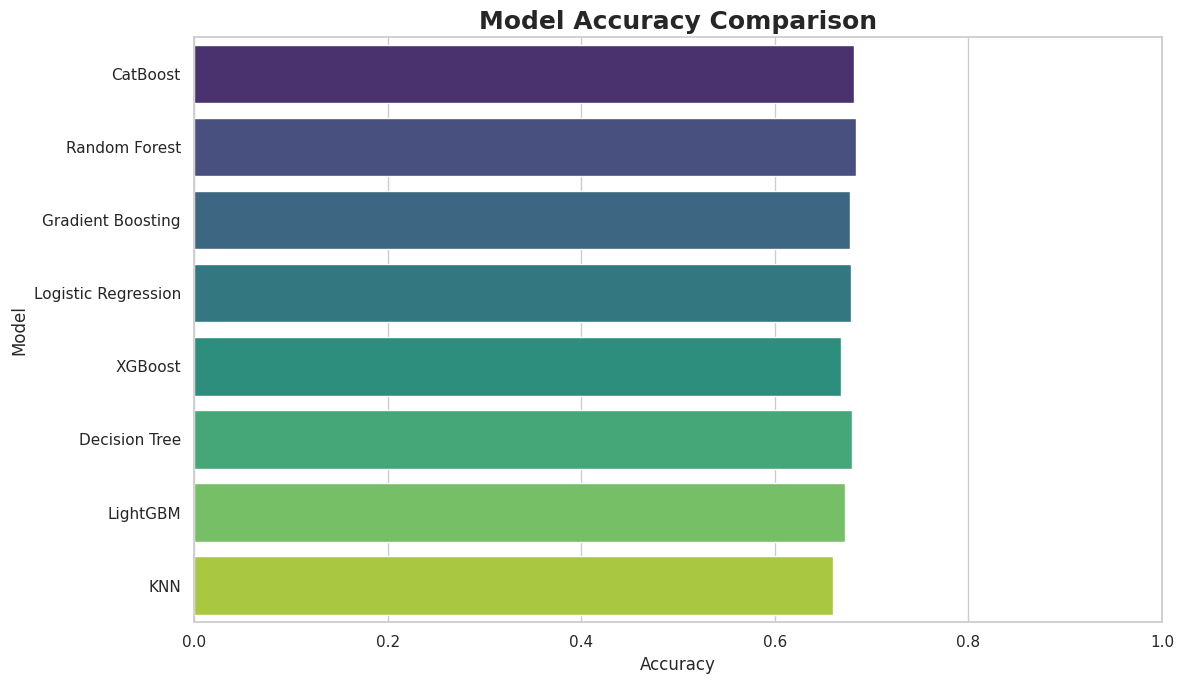

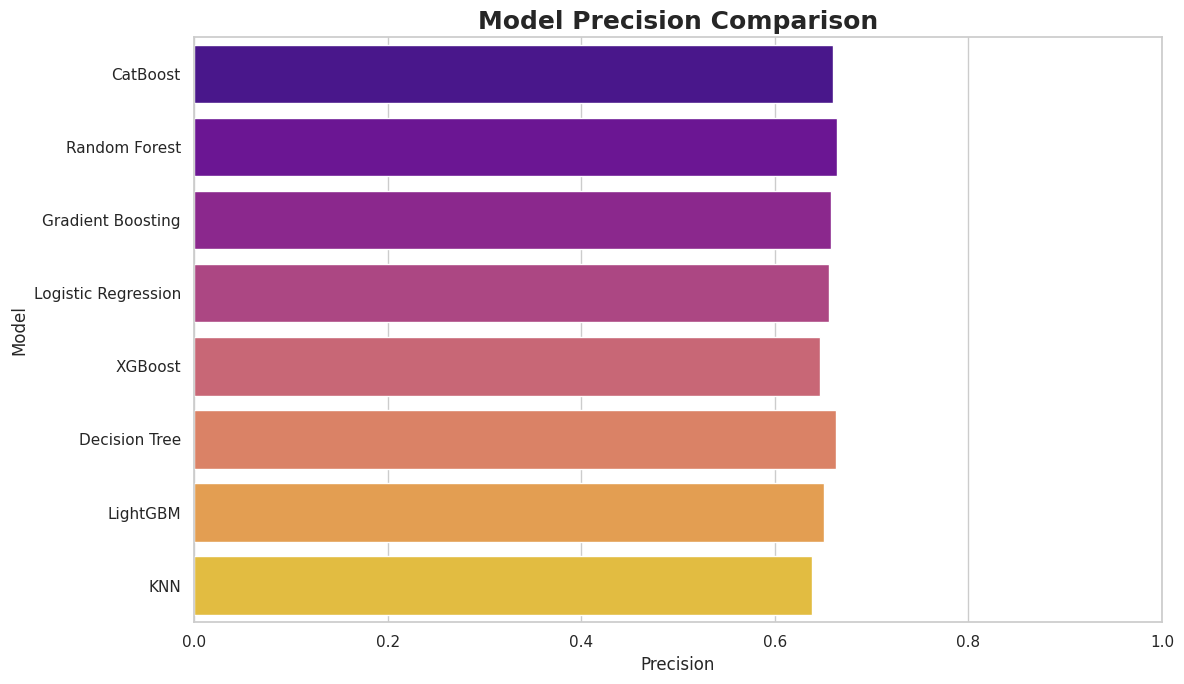

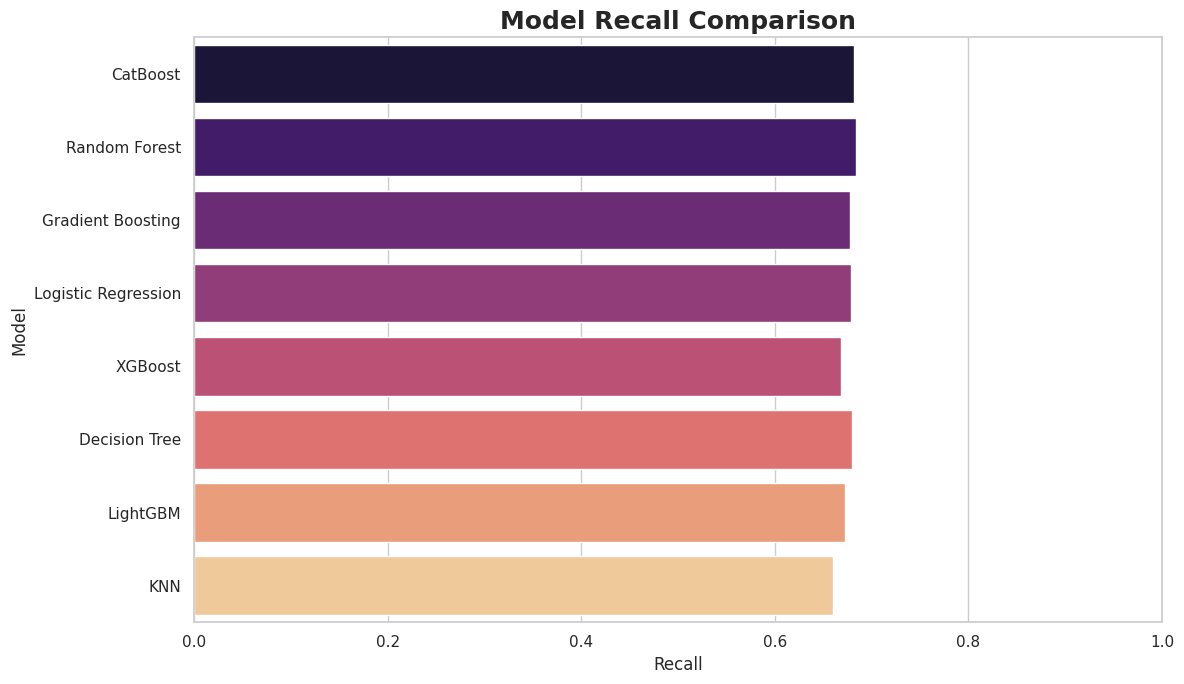

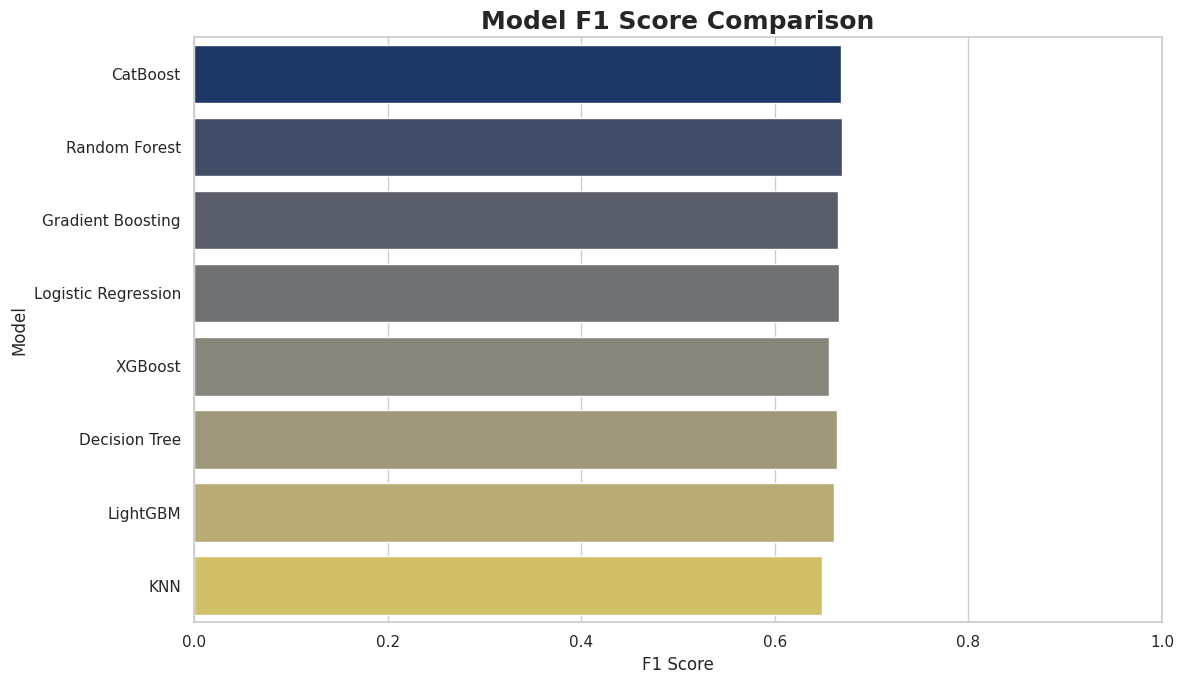

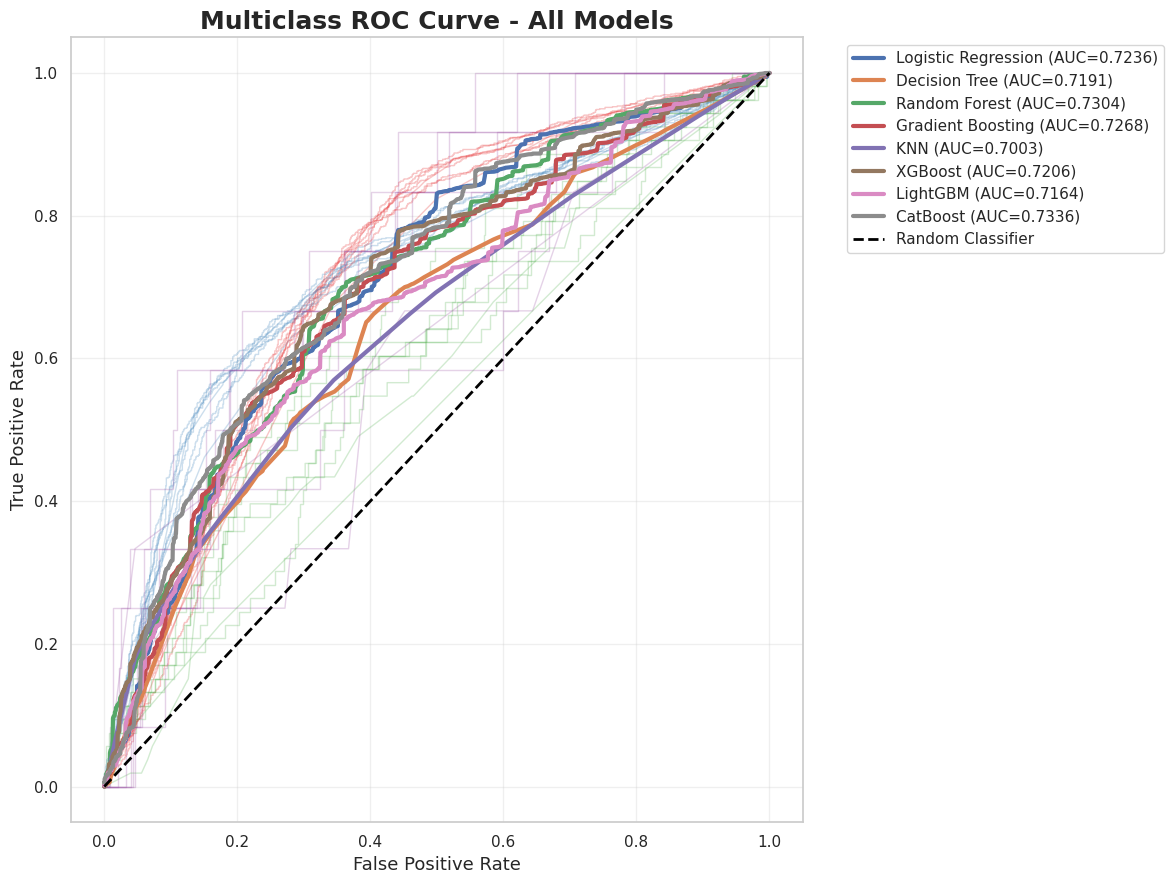

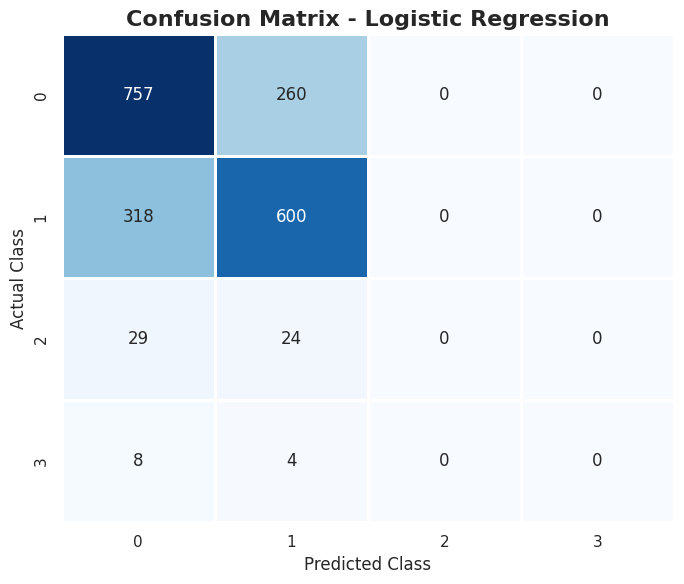

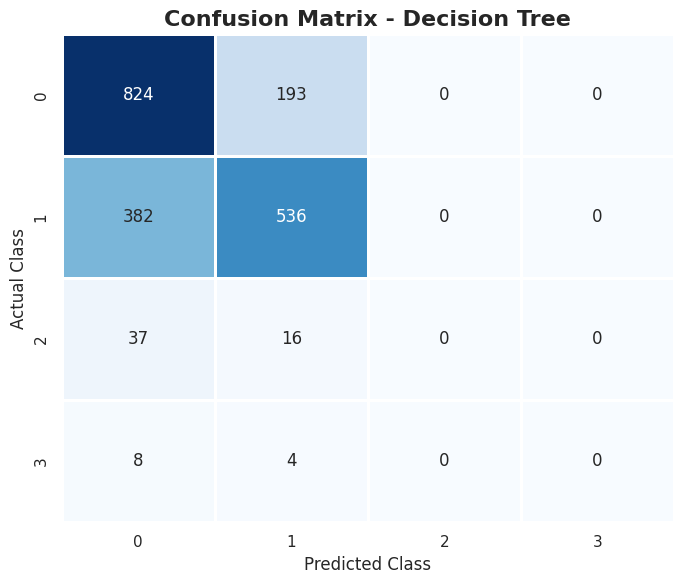

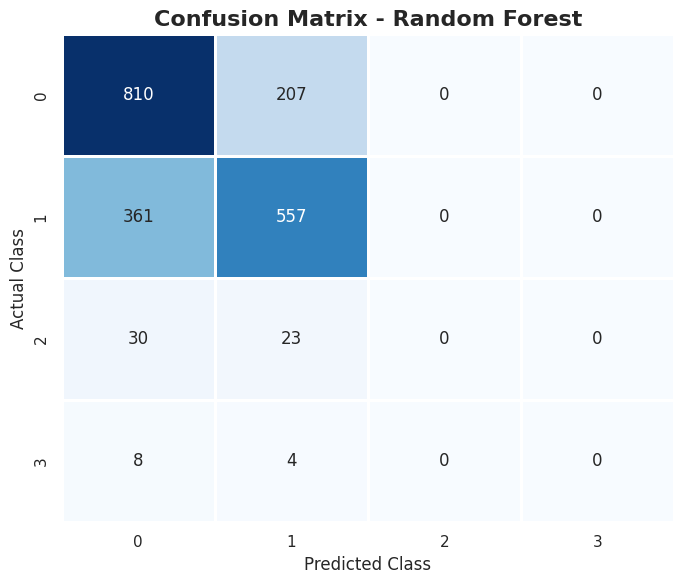

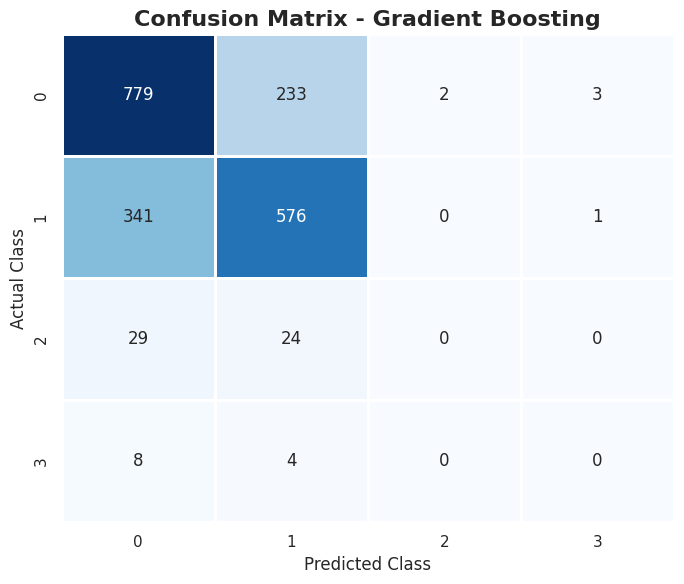

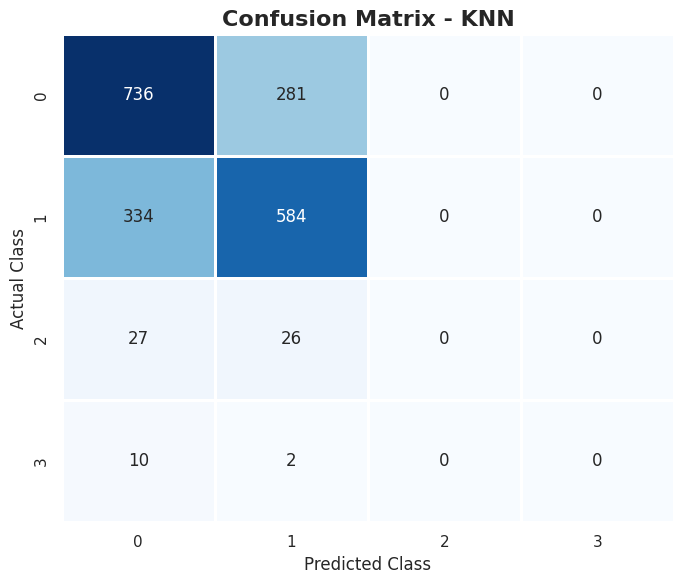

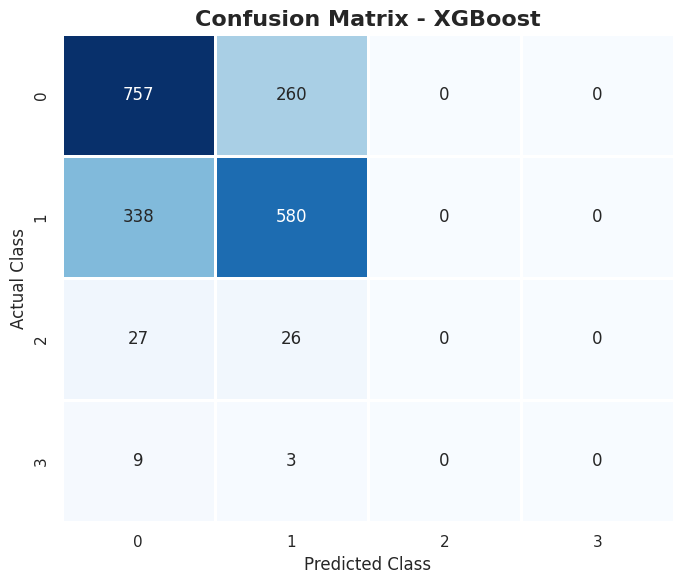

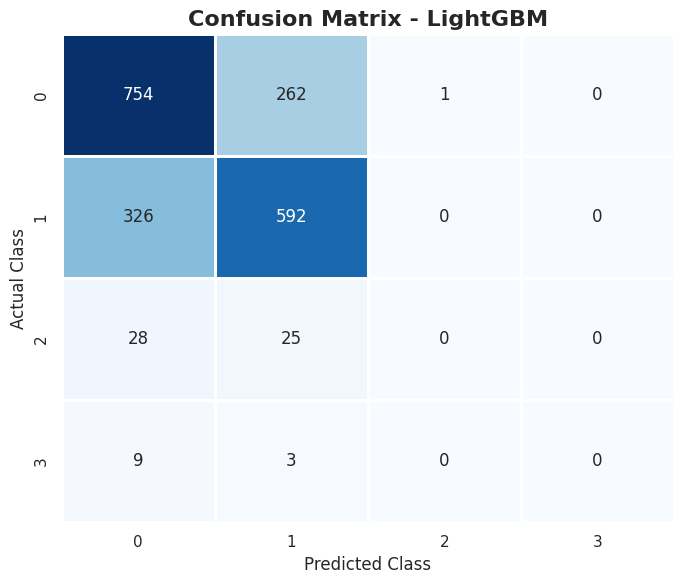

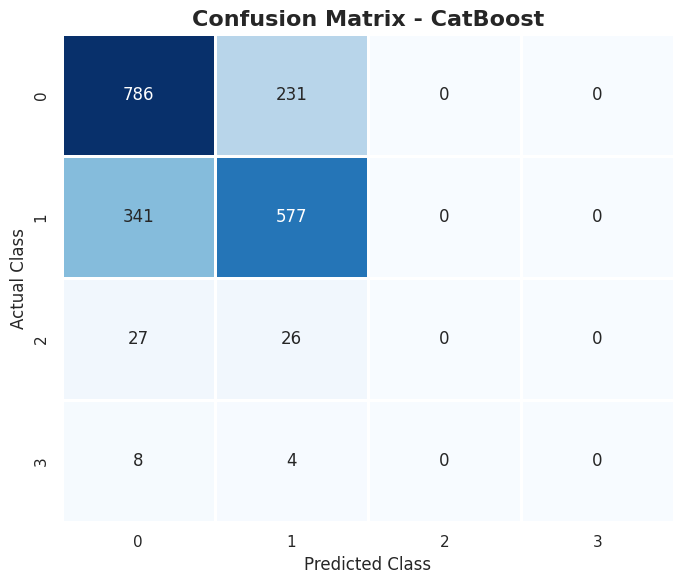



CLASSIFICATION REPORT: Logistic Regression
              precision    recall  f1-score   support

           1       0.68      0.74      0.71      1017
           2       0.68      0.65      0.66       918
           3       0.00      0.00      0.00        53
           4       0.00      0.00      0.00        12

    accuracy                           0.68      2000
   macro avg       0.34      0.35      0.34      2000
weighted avg       0.66      0.68      0.67      2000



CLASSIFICATION REPORT: Decision Tree
              precision    recall  f1-score   support

           1       0.66      0.81      0.73      1017
           2       0.72      0.58      0.64       918
           3       0.00      0.00      0.00        53
           4       0.00      0.00      0.00        12

    accuracy                           0.68      2000
   macro avg       0.34      0.35      0.34      2000
weighted avg       0.66      0.68      0.66      2000



CLASSIFICATION REPORT: Random Forest
       

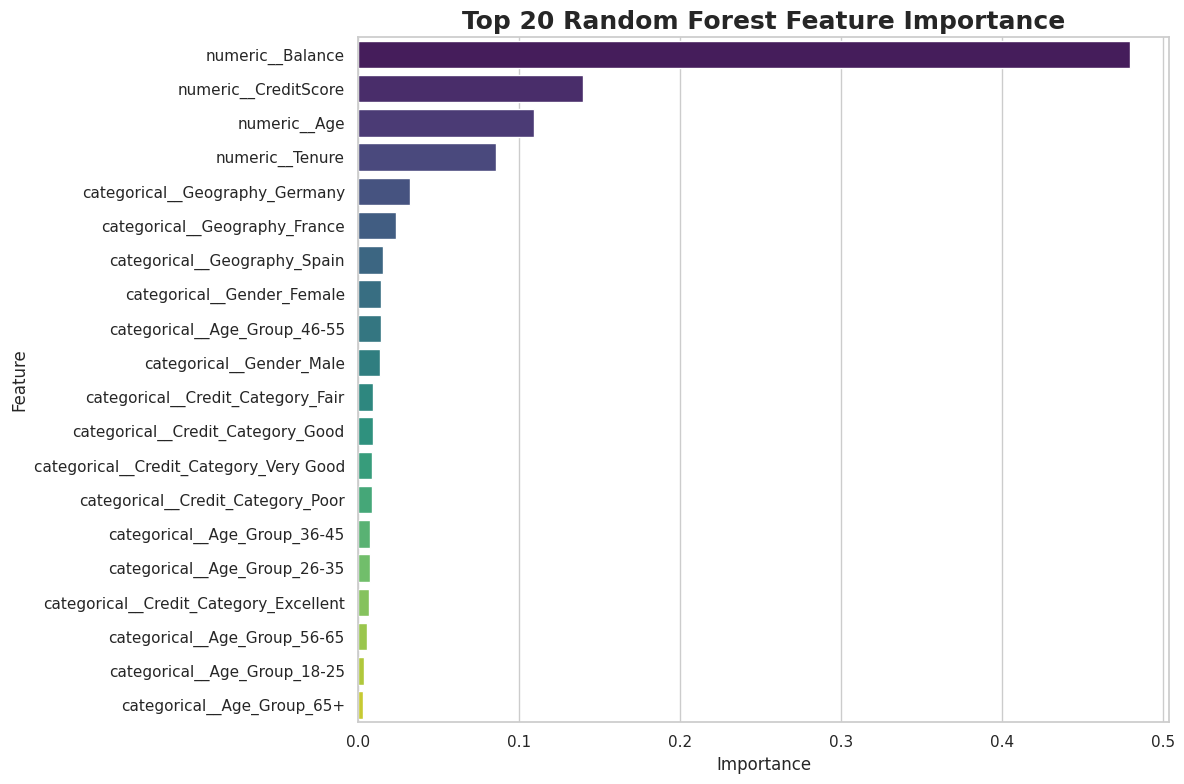

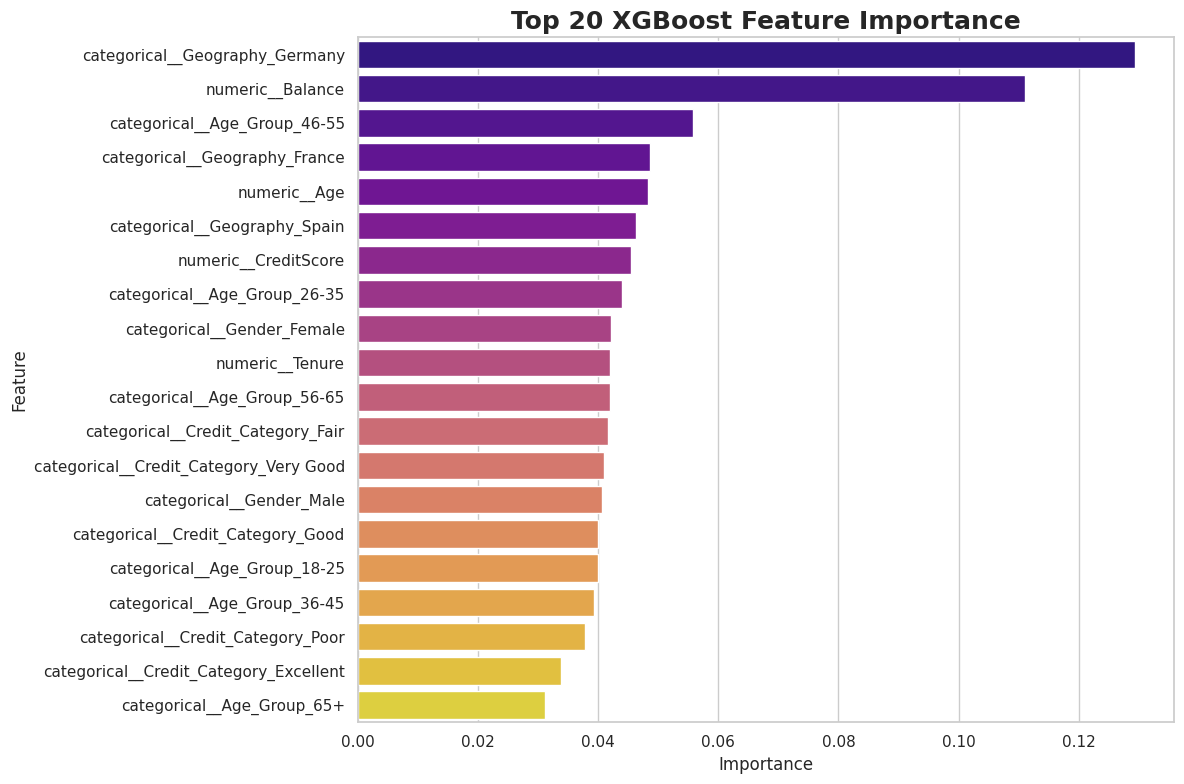

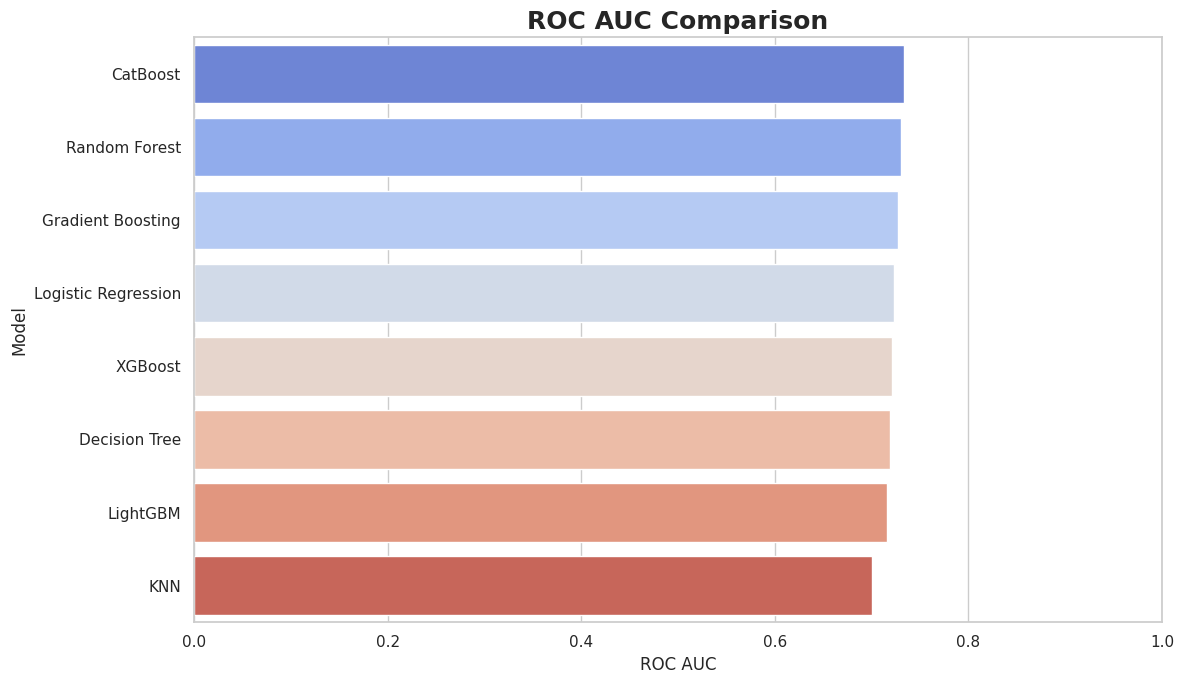


FINAL MODEL RESULTS


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
7,CatBoost,68.15,66.00,68.15,66.85,0.7336
2,Random Forest,68.35,66.39,68.35,66.93,0.7304
3,Gradient Boosting,67.75,65.82,67.75,66.57,0.7268
0,Logistic Regression,67.85,65.63,67.85,66.66,0.7236
5,XGBoost,66.85,64.67,66.85,65.64,0.7206
1,Decision Tree,68.00,66.34,68.00,66.47,0.7191
6,LightGBM,67.30,65.13,67.30,66.13,0.7164
4,KNN,66.00,63.83,66.00,64.84,0.7003



ML PROCESS COMPLETED SUCCESSFULLY


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# ============================================================
# 2. CHECK DATA
# ============================================================

print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())


# ============================================================
# 3. CHECK REQUIRED COLUMNS
# ============================================================

required_columns = [
    "CreditScore",
    "Geography",
    "Gender",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if len(missing_columns) > 0:

    raise ValueError(
        f"These required columns are missing: {missing_columns}"
    )

print("\nAll required columns are available.")


# ============================================================
# 4. REMOVE UNNECESSARY IDENTIFIER COLUMNS
# ============================================================

remove_columns = [
    "RowNumber",
    "CustomerId",
    "Surname"
]

remove_columns = [
    col for col in remove_columns
    if col in df.columns
]

data = df.drop(
    columns=remove_columns
).copy()


# ============================================================
# 5. DEFINE FEATURES AND TARGET
# ============================================================

# TARGET
# We are predicting NumOfProducts

target = "NumOfProducts"

X = data.drop(
    columns=[target]
)

y = data[target]


print("\n" + "=" * 80)
print("FEATURES AND TARGET")
print("=" * 80)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(target)

print("\nTarget Distribution:")
print(y.value_counts().sort_index())


# ============================================================
# 6. REMOVE RARE TARGET CLASSES
# ============================================================

# Some datasets may contain very few examples
# for certain product classes.

target_counts = y.value_counts()

valid_classes = target_counts[
    target_counts >= 2
].index

mask = y.isin(valid_classes)

X = X.loc[mask].copy()
y = y.loc[mask].copy()

print("\nTarget Distribution After Checking:")
print(y.value_counts().sort_index())


# ============================================================
# 7. LABEL ENCODE TARGET
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("\nOriginal Target Classes:")
print(label_encoder.classes_)

print("\nEncoded Target Classes:")
print(np.unique(y_encoded))


# ============================================================
# 8. IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# ============================================================

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nNumerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


# ============================================================
# 9. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("\n" + "=" * 80)
print("TRAIN TEST SPLIT")
print("=" * 80)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ============================================================
# 10. PREPROCESSING
# ============================================================

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ============================================================
# 11. DEFINE ML ALGORITHMS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=6,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=7
        ),

    "XGBoost":
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="mlogloss",
            random_state=42
        ),

    "LightGBM":
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            num_leaves=31,
            random_state=42,
            verbose=-1
        ),

    "CatBoost":
        CatBoostClassifier(
            iterations=300,
            learning_rate=0.05,
            depth=6,
            verbose=False,
            random_state=42
        )
}


# ============================================================
# 12. TRAIN MODELS
# ============================================================

results = []

trained_models = {}

predictions = {}

probabilities = {}

roc_data = {}


for model_name, model in models.items():

    print("\n" + "=" * 80)
    print("TRAINING:", model_name)
    print("=" * 80)

    # Pipeline
    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    # Train
    pipeline.fit(
        X_train,
        y_train
    )

    # Prediction
    y_pred = pipeline.predict(X_test)

    # Probability
    y_prob = pipeline.predict_proba(X_test)

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # Multiclass ROC AUC
    auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr",
        average="weighted"
    )

    # Store results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": auc
    })

    trained_models[model_name] = pipeline
    predictions[model_name] = y_pred
    probabilities[model_name] = y_prob

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {auc:.4f}")


# ============================================================
# 13. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC AUC",
    ascending=False
)

print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1 Score": "{:.2%}",
        "ROC AUC": "{:.4f}"
    })
)


# ============================================================
# 14. ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title(
    "Model Accuracy Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.tight_layout()
plt.show()


# ============================================================
# 15. PRECISION COMPARISON
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=results_df,
    x="Precision",
    y="Model",
    hue="Model",
    palette="plasma",
    legend=False
)

plt.title(
    "Model Precision Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Precision")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.tight_layout()
plt.show()


# ============================================================
# 16. RECALL COMPARISON
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=results_df,
    x="Recall",
    y="Model",
    hue="Model",
    palette="magma",
    legend=False
)

plt.title(
    "Model Recall Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Recall")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.tight_layout()
plt.show()


# ============================================================
# 17. F1 SCORE COMPARISON
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=results_df,
    x="F1 Score",
    y="Model",
    hue="Model",
    palette="cividis",
    legend=False
)

plt.title(
    "Model F1 Score Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("F1 Score")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.tight_layout()
plt.show()


# ============================================================
# 18. MULTICLASS ROC CURVES
# ============================================================

n_classes = len(
    np.unique(y_test)
)

plt.figure(figsize=(12, 9))

roc_colors = [
    "#E41A1C",
    "#377EB8",
    "#4DAF4A",
    "#984EA3",
    "#FF7F00",
    "#A65628",
    "#F781BF",
    "#17BECF"
]


for model_index, (
    model_name,
    y_prob
) in enumerate(probabilities.items()):

    # Plot one-vs-rest ROC for each class
    for class_index in range(n_classes):

        binary_y_test = (
            y_test == class_index
        ).astype(int)

        fpr, tpr, _ = roc_curve(
            binary_y_test,
            y_prob[:, class_index]
        )

        auc_score = roc_auc_score(
            binary_y_test,
            y_prob[:, class_index]
        )

        plt.plot(
            fpr,
            tpr,
            color=roc_colors[
                class_index % len(roc_colors)
            ],
            alpha=0.25,
            linewidth=1
        )


# Plot macro-style ROC for every model

for model_index, (
    model_name,
    y_prob
) in enumerate(probabilities.items()):

    all_fpr = np.unique(
        np.concatenate([
            roc_curve(
                (y_test == class_index).astype(int),
                y_prob[:, class_index]
            )[0]
            for class_index in range(n_classes)
        ])
    )

    mean_tpr = np.zeros_like(all_fpr)

    for class_index in range(n_classes):

        binary_y_test = (
            y_test == class_index
        ).astype(int)

        fpr, tpr, _ = roc_curve(
            binary_y_test,
            y_prob[:, class_index]
        )

        mean_tpr += np.interp(
            all_fpr,
            fpr,
            tpr
        )

    mean_tpr /= n_classes

    auc_score = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr",
        average="weighted"
    )

    plt.plot(
        all_fpr,
        mean_tpr,
        linewidth=3,
        label=f"{model_name} (AUC={auc_score:.4f})"
    )


# Random classifier

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    color="black",
    linewidth=2,
    label="Random Classifier"
)

plt.title(
    "Multiclass ROC Curve - All Models",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=13
)

plt.ylabel(
    "True Positive Rate",
    fontsize=13
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 19. CONFUSION MATRICES
# ============================================================

for model_name in trained_models:

    cm = confusion_matrix(
        y_test,
        predictions[model_name]
    )

    plt.figure(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidths=1,
        cbar=False
    )

    plt.title(
        f"Confusion Matrix - {model_name}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.tight_layout()
    plt.show()


# ============================================================
# 20. CLASSIFICATION REPORTS
# ============================================================

for model_name in trained_models:

    print("\n")
    print("=" * 80)
    print("CLASSIFICATION REPORT:", model_name)
    print("=" * 80)

    print(
        classification_report(
            y_test,
            predictions[model_name],
            target_names=[
                str(x)
                for x in label_encoder.classes_
            ],
            zero_division=0
        )
    )


# ============================================================
# 21. FEATURE IMPORTANCE - RANDOM FOREST
# ============================================================

rf_pipeline = trained_models[
    "Random Forest"
]

rf_preprocessor = (
    rf_pipeline
    .named_steps["preprocessor"]
)

rf_model = (
    rf_pipeline
    .named_steps["model"]
)

feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

importance = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title(
    "Top 20 Random Forest Feature Importance",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


# ============================================================
# 22. XGBOOST FEATURE IMPORTANCE
# ============================================================

xgb_pipeline = trained_models[
    "XGBoost"
]

xgb_preprocessor = (
    xgb_pipeline
    .named_steps["preprocessor"]
)

xgb_model = (
    xgb_pipeline
    .named_steps["model"]
)

xgb_feature_names = (
    xgb_preprocessor
    .get_feature_names_out()
)

xgb_importance = (
    xgb_model
    .feature_importances_
)

xgb_df = pd.DataFrame({
    "Feature": xgb_feature_names,
    "Importance": xgb_importance
})

xgb_df = (
    xgb_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=xgb_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="plasma",
    legend=False
)

plt.title(
    "Top 20 XGBoost Feature Importance",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


# ============================================================
# 23. ROC AUC COMPARISON
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=results_df,
    x="ROC AUC",
    y="Model",
    hue="Model",
    palette="coolwarm",
    legend=False
)

plt.title(
    "ROC AUC Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("ROC AUC")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.tight_layout()
plt.show()


# ============================================================
# 24. FINAL RESULTS
# ============================================================

print("\n" + "=" * 80)
print("FINAL MODEL RESULTS")
print("=" * 80)

final_results = results_df.copy()

final_results[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
] *= 100

final_results[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
] = final_results[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
].round(2)

final_results["ROC AUC"] = (
    final_results["ROC AUC"]
    .round(4)
)

display(final_results)


print("\n" + "=" * 80)
print("ML PROCESS COMPLETED SUCCESSFULLY")
print("=" * 80)

## Thank you..pls upvote!!!!!